In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

import shapiq
from shapiq import TabularExplainer
from shapiq.datasets import load_bike_sharing_daily, load_bike_sharing_daily_train_index

print(f"shapiq version: {shapiq.__version__}")

e:\Desktop\Shapley\Shapiq\shapiq\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


shapiq version: None


## 1. Load Bike Sharing Daily Data

The paper uses the UCI Bike Sharing Dataset (daily aggregates) with specific preprocessing:
- **trend**: Days since January 1, 2011
- **cosyear**: cos(2π × trend / 365) - cyclical season
- **sinyear**: sin(2π × trend / 365) - cyclical season
- **temp**: Unnormalized temperature (°C)
- **atemp**: Unnormalized feeling temperature (°C)
- **windspeed**: Unnormalized wind speed
- **hum**: Unnormalized humidity (%)
- **location**: Constant feature (value = 1.0) representing a single location for all samples. 

> **Source**: [`src/shapiq/datasets/_all.py`](../../src/shapiq/datasets/_all.py) → `load_bike_sharing_daily()` (Line 73-134)
>
> **Note**: The `location` feature is not in the original dataset but is added in this notebook to demonstrate an alternative causal ordering where location serves as a root cause alongside temporal trend (see Section 3 for the complete causal graph).

In [2]:
# Load preprocessed data from shapiq.datasets
x_data, y_data = load_bike_sharing_daily(preprocessed=True)
train_idx = load_bike_sharing_daily_train_index()

# Add location as a constant feature (same location for all samples)
x_data = x_data.copy()
x_data['location'] = 1.0  # Constant value representing a single location

feature_names = ["trend", "cosyear", "sinyear", "temp", "atemp", "windspeed", "hum", "location"]

# Create train/test split
all_idx = np.arange(len(x_data))
test_idx = np.array([i for i in all_idx if i not in train_idx])

print(f"Total samples: {len(x_data)} (CSV rows 2-732 in day.csv)")
print(f"Training samples: {len(train_idx)} (indices from train_index.npy)")
print(f"Test samples: {len(test_idx)} (DataFrame indices: {test_idx.tolist()[:10]}...{test_idx.tolist()[-5:]})")
print(f"Test CSV rows: {(test_idx + 2).tolist()[:10]}...{(test_idx + 2).tolist()[-5:]}")
print(f"Features: {feature_names}")
print(f"Note: 'location' is a constant feature added for causal structure")

Total samples: 731 (CSV rows 2-732 in day.csv)
Training samples: 587 (indices from train_index.npy)
Test samples: 144 (DataFrame indices: [13, 14, 29, 32, 37, 41, 44, 46, 48, 50]...[702, 706, 713, 719, 726])
Test CSV rows: [15, 16, 31, 34, 39, 43, 46, 48, 50, 52]...[704, 708, 715, 721, 728]
Features: ['trend', 'cosyear', 'sinyear', 'temp', 'atemp', 'windspeed', 'hum', 'location']
Note: 'location' is a constant feature added for causal structure


In [3]:
# Prepare data with centering (as in original paper)
X_train = x_data.iloc[train_idx].values
y_train_nc = y_data.iloc[train_idx].values  # not centered
y_train_mean = y_train_nc.mean()
y_train = y_train_nc - y_train_mean  # centered

X_test = x_data.iloc[test_idx].values
y_test = y_data.iloc[test_idx].values - y_train_mean  # centered using train mean

print(f"y_train mean (φ₀): {y_train_mean:.2f}")

y_train mean (φ₀): 4505.03


## 1.1. Data Visualization: Bike Rentals Over Time

Before training the model, let's visualize the raw data to understand the relationship between time, temperature, and bike rentals. This reproduces the exploratory data analysis from the paper.

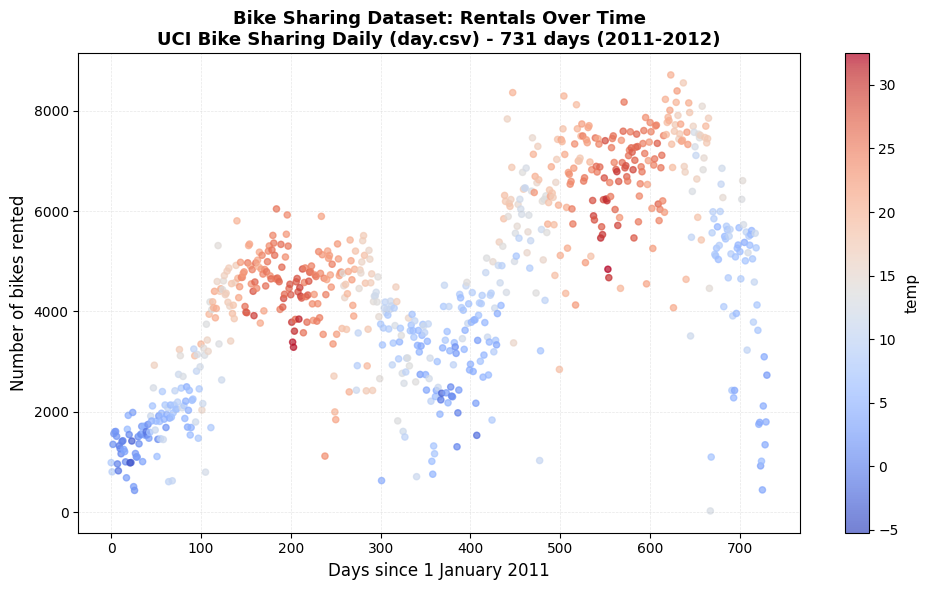


Data Patterns Observed:
1. TREND: Bike rentals generally increase over time (2011-2012)
2. SEASONALITY: Clear seasonal pattern with peaks in warm months
3. TEMPERATURE: Warmer days (red) tend to have more rentals
4. The correlation between temp and rentals is confounded by season


In [4]:
# Visualize: Number of bikes rented over time, colored by temperature
# This shows the raw data patterns before Shapley analysis

fig, ax = plt.subplots(figsize=(10, 6))

# Use full dataset for visualization (not centered)
# Note: x_data now includes the 'location' feature, but we use original features for viz
trend_values = x_data['trend'].values
temp_values = x_data['temp'].values
y_values = y_data.values  # Original bike rental counts (not centered)

# Create scatter plot
scatter = ax.scatter(trend_values, y_values, c=temp_values, 
                     cmap='coolwarm', s=20, alpha=0.7)

ax.set_xlabel('Days since 1 January 2011', fontsize=12)
ax.set_ylabel('Number of bikes rented', fontsize=12)
ax.set_title('Bike Sharing Dataset: Rentals Over Time\n'
             'UCI Bike Sharing Daily (day.csv) - 731 days (2011-2012)', 
             fontsize=13, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('temp', fontsize=11)

# Add grid for better readability
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

print("\nData Patterns Observed:")
print("=" * 60)
print("1. TREND: Bike rentals generally increase over time (2011-2012)")
print("2. SEASONALITY: Clear seasonal pattern with peaks in warm months")
print("3. TEMPERATURE: Warmer days (red) tend to have more rentals")
print("4. The correlation between temp and rentals is confounded by season")
print("=" * 60)

## 2. Train XGBoost Model

In [5]:
model = xgb.XGBRegressor(
    n_estimators=100,
    random_state=1,
    verbosity=0
)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
print(f"Test RMSE (centered): {rmse:.2f}")

Test RMSE (centered): 775.24


## 3. Define Alternative Causal Structure

This notebook uses an **alternative causal ordering** different from the original paper:

```
[trend, location]  (Layer 1: Root causes)
       |
       v
[cosyear, sinyear, temp, hum, windspeed]  (Layer 2: Season & Weather)
       |                                    ← atmospheric_state (unobserved confounder)
       v
    [atemp]  (Layer 3: Feeling temperature)
       |
       v
    [count]  (Target: bike rentals)
```

Key differences from the original paper:
- **Location** is added as a constant feature (same location for all samples)
- **Layer 2 confounding**: `atmospheric_state` acts as an unobserved common cause of the weather variables in Layer 2. Although it cannot be directly measured, setting `confounding = True` for this layer instructs the imputer to perform **joint sampling** (rather than independent sampling) of cosyear, sinyear, temp, hum, and windspeed, thereby preserving their natural correlation structure. Layer 1 (exogenous time variables) and Layer 3 (single variable) do not require this treatment.
- **atemp (feeling temperature)** is in a separate layer as it depends on temp, humidity, and windspeed
- This structure treats season (cosyear, sinyear) and weather (temp, hum, windspeed) as being at the same causal level

In [6]:
# Alternative causal ordering:
# Layer 1: [trend, location] - root causes (date and location)
# Layer 2: [cosyear, sinyear, temp, hum, windspeed] - season and weather variables
# Layer 3: [atemp] - feeling temperature depends on temp, humidity, windspeed

# Feature indices:
# 0: trend, 1: cosyear, 2: sinyear, 3: temp, 4: atemp, 5: windspeed, 6: hum, 7: location

ordering = [
    [0, 7],              # Layer 1: trend, location (root causes)
    [1, 2, 3, 6, 5],     # Layer 2: cosyear, sinyear, temp, hum, windspeed
    [4],                 # Layer 3: atemp (feeling temperature)
]

# Confounding flags per layer:
# Layer 1 (False): exogenous root causes — no unobserved common cause
# Layer 2 (True):  atmospheric_state is an unobserved confounder → joint sampling
# Layer 3 (False): single variable — confounding is irrelevant
confounding = [False, True, False]

print("Alternative Causal Structure:")
for i, layer in enumerate(ordering):
    layer_names = [feature_names[j] for j in layer]
    print(f"  Layer {i+1}: {layer_names} (confounding={confounding[i]})")

print("\nCausal Graph:")
print("  [trend, location]")
print("         |")
print("         v")
print("  [cosyear, sinyear, temp, hum, windspeed]")
print("    ← atmospheric_state (unobserved confounder, confounding=True)")
print("         |")
print("         v")
print("      [atemp]")
print("         |")
print("         v")
print("      [count]")

Alternative Causal Structure:
  Layer 1: ['trend', 'location'] (confounding=False)
  Layer 2: ['cosyear', 'sinyear', 'temp', 'hum', 'windspeed'] (confounding=True)
  Layer 3: ['atemp'] (confounding=False)

Causal Graph:
  [trend, location]
         |
         v
  [cosyear, sinyear, temp, hum, windspeed]
    ← atmospheric_state (unobserved confounder, confounding=True)
         |
         v
      [atemp]
         |
         v
      [count]


## 4. Create Explainers

- **Marginal**: Standard SHAP (assumes feature independence)
- **Causal**: Uses CausalImputer with copula sampling and the **alternative ordering**:
  - Layer 1: `[trend, location]` → Layer 2: `[cosyear, sinyear, temp, hum, windspeed]` → Layer 3: `[atemp]`
  - Layer 2 has `confounding = True` (unobserved `atmospheric_state` as common cause → joint sampling to preserve weather variable correlations)

> **Note on Sampling Methods**: This notebook uses **Copula sampling only** (not Gaussian) for the following reasons:
> 1. **Constant feature handling**: Gaussian sampling does not handle constant features (like `location`) well
> 2. **Marginal distribution preservation**: Copula preserves the original marginal distributions, which is more robust for non-Gaussian data like bike rentals
> 3. **Empirical evidence**: As shown in [`paper_figure3_reproduction.ipynb`](./paper_figure3_reproduction.ipynb), Gaussian vs Copula methods show minimal differences in results, making Copula the preferred choice due to its better theoretical properties and broader applicability

In [ ]:
# Configuration
RANDOM_STATE = 42
SAMPLE_SIZE = 1000

# Dictionary to store all explainers
explainers = {}

# =============================================================================
# 1. MARGINAL EXPLAINERS (No causal structure)
# =============================================================================

# 1a. Marginal (Joint) - Standard SHAP with joint marginal sampling
#     (empirical resampling, independent feature permutation)
explainers['Marginal (Joint)'] = TabularExplainer(
    model=model.predict,
    data=X_train,
    imputer="marginal",
    index="k-SII",
    max_order=2,
    random_state=RANDOM_STATE
)

# 1b. Marginal (Copula) - Gaussian Copula, no causal structure
#     sampling_method="copula" → Gaussian copula preserving original marginal distributions
explainers['Marginal (Copula)'] = TabularExplainer(
    model=model.predict,
    data=X_train,
    imputer="marginal",
    sampling_method="copula",
    sample_size=SAMPLE_SIZE,
    index="k-SII",
    max_order=2,
    random_state=RANDOM_STATE
)

# =============================================================================
# 2. CAUSAL EXPLAINERS WITH MODEL (XGBoost)
# =============================================================================

# 2. Causal + Model (Copula sampling) - With preserved marginals
explainers['Causal+Model (Copula)'] = TabularExplainer(
    model=model.predict,
    data=X_train,
    imputer="causal",  # unified string API
    ordering=ordering,
    confounding=confounding,
    sampling_method="copula",
    sample_size=SAMPLE_SIZE,
    index="k-SII",
    max_order=2,
    random_state=RANDOM_STATE
)

# =============================================================================
# 3. CAUSAL EXPLAINER WITHOUT MODEL (Model-Free)
# =============================================================================

# 3. No-Model Causal - treats Y as final node in causal graph
#    NoModelCausalImputer internally builds a linear conditional Gaussian model
#    for Y and a CausalImputer for X, both sharing the same covariance structure.
explainers['Causal No-Model (Copula)'] = TabularExplainer(
    model=model.predict,       # placeholder; overridden internally by NoModelCausalImputer.predict
    data=X_train,
    imputer="no_model_causal", # unified string API
    y=y_train,                 # target values (required for model-free Y estimation)
    ordering=ordering,
    confounding=confounding,
    sampling_method="copula",
    sample_size=SAMPLE_SIZE,
    index="k-SII",
    max_order=2,
    random_state=RANDOM_STATE
)

print("All explainers created successfully!")
print(f"\nTotal explainers: {len(explainers)}")
print("\nMethods:")
for name in explainers:
    print(f"  - {name}")

All explainers created successfully!

Total explainers: 4

Methods:
  - Marginal (Joint)  [Paper MSV]
  - Marginal (Copula)
  - Causal+Model (Copula)
  - Causal No-Model (Copula)


## 5. Compute Shapley Values for All Test Samples

>  **Note**: This step computes Shapley values for all 4 methods across all test samples. Expected runtime: **55-75 minutes** depending on your hardware.

In [8]:
budget = 2048
n_features = len(feature_names)

# Store all k-SII results (InteractionValues objects) and extracted 1st-order values
all_ksii = {}  # Full InteractionValues for each sample
all_sv = {}    # 1st-order values only (for backward compatibility with existing plots)

for exp_name, explainer in explainers.items():
    print(f"\nComputing k-SII (max_order=2) for {exp_name} across {len(X_test)} samples...")
    ksii_list = []  # Store full InteractionValues for each sample
    sv = np.zeros((len(X_test), n_features))
    
    for i in range(len(X_test)):
        result = explainer.explain(X_test[i:i+1], budget=budget)
        ksii_list.append(result)  # Store full result with interactions
        sv[i] = result.get_n_order_values(order=1)  # Extract 1st-order for backward compat
        if (i + 1) % 50 == 0:
            print(f"  Processed {i + 1}/{len(X_test)}")
    
    all_ksii[exp_name] = ksii_list
    all_sv[exp_name] = sv
    print(f"  Done!")

print("\n" + "="*50)
print("All k-SII values (1st & 2nd order) computed successfully!")
print("="*50)
print(f"\nStored data:")
print(f"  all_ksii: Full InteractionValues for each sample (includes 2nd-order interactions)")
print(f"  all_sv: 1st-order values only (n_samples x n_features arrays)")


Computing k-SII (max_order=2) for Marginal (Joint) across 144 samples...


E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is req

  Processed 50/144


E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is req

  Processed 100/144


...

  Processed 50/144


E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is req

  Processed 100/144


E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is req

  Done!

All k-SII values (1st & 2nd order) computed successfully!

Stored data:
  all_ksii: Full InteractionValues for each sample (includes 2nd-order interactions)
  all_sv: 1st-order values only (n_samples x n_features arrays)


## 6. Scatter Plots: 2×2 Grid Comparison

In [9]:
# For paper reproduction: use only the two methods
# - MSV: Marginal (Joint) = standard marginal SHAP
# - CSV: Causal+Model (Copula) = causal method with copula sampling
sv_marginal = all_sv['Marginal (Joint)']
sv_causal = all_sv['Causal+Model (Copula)']

C:\Users\bodun\AppData\Local\Temp\ipykernel_11292\3253742336.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 0.92])


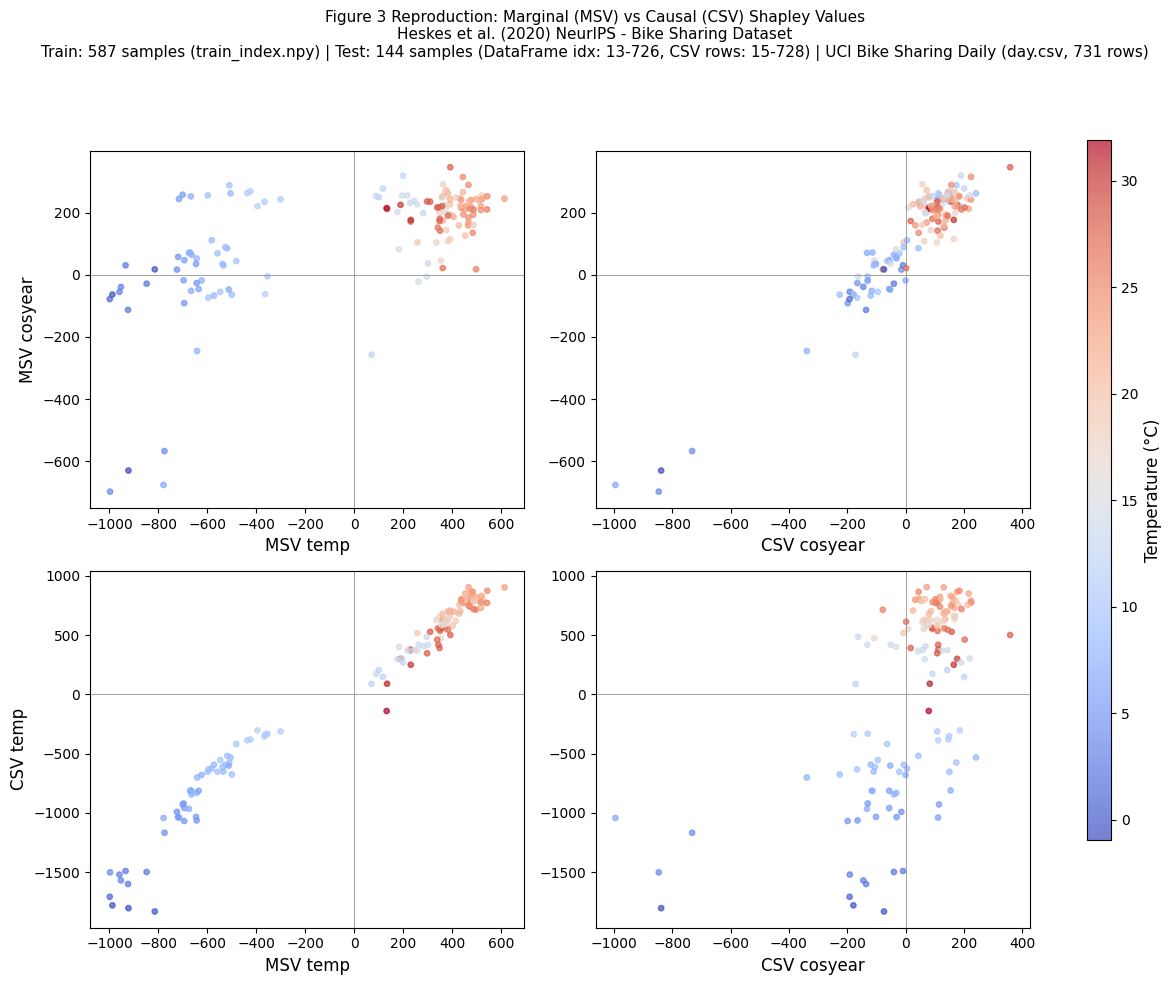

In [10]:
# Get feature indices
temp_idx = feature_names.index('temp')
cosyear_idx = feature_names.index('cosyear')

# Get Shapley values for temp and cosyear
sv_marg_temp = sv_marginal[:, temp_idx]
sv_marg_cosyear = sv_marginal[:, cosyear_idx]
sv_caus_temp = sv_causal[:, temp_idx]
sv_caus_cosyear = sv_causal[:, cosyear_idx]

# Temperature values for coloring
temp_values = X_test[:, temp_idx]

# Create 2x2 figure matching paper layout (wider to accommodate colorbar)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

cmap = 'coolwarm'
point_size = 15

# Top left: MSV temp (x) vs MSV cosyear (y)
ax = axes[0, 0]
scatter = ax.scatter(sv_marg_temp, sv_marg_cosyear, c=temp_values, 
                    cmap=cmap, s=point_size, alpha=0.7)
ax.set_xlabel('MSV temp', fontsize=12)
ax.set_ylabel('MSV cosyear', fontsize=12)
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5)

# Top right: CSV cosyear (x) vs MSV cosyear (y)
ax = axes[0, 1]
ax.scatter(sv_caus_cosyear, sv_marg_cosyear, c=temp_values,
          cmap=cmap, s=point_size, alpha=0.7)
ax.set_xlabel('CSV cosyear', fontsize=12)
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5)

# Bottom left: MSV temp (x) vs CSV temp (y)
ax = axes[1, 0]
ax.scatter(sv_marg_temp, sv_caus_temp, c=temp_values,
          cmap=cmap, s=point_size, alpha=0.7)
ax.set_xlabel('MSV temp', fontsize=12)
ax.set_ylabel('CSV temp', fontsize=12)
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5)

# Bottom right: CSV cosyear (x) vs CSV temp (y)
ax = axes[1, 1]
scatter = ax.scatter(sv_caus_cosyear, sv_caus_temp, c=temp_values,
                    cmap=cmap, s=point_size, alpha=0.7)
ax.set_xlabel('CSV cosyear', fontsize=12)
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5)

# Add colorbar with better positioning
fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
cbar = fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label('Temperature (°C)', fontsize=12)

# Get test CSV rows for display
test_csv_rows = test_idx + 2
plt.suptitle('Figure 3 Reproduction: Marginal (MSV) vs Causal (CSV) Shapley Values\n'
             'Heskes et al. (2020) NeurIPS - Bike Sharing Dataset\n'
             f'Train: {len(train_idx)} samples (train_index.npy) | '
             f'Test: {len(test_idx)} samples (DataFrame idx: {test_idx[0]}-{test_idx[-1]}, CSV rows: {test_csv_rows[0]}-{test_csv_rows[-1]}) | '
             f'UCI Bike Sharing Daily (day.csv, 731 rows)', fontsize=11)
plt.tight_layout(rect=[0, 0, 0.88, 0.92])
plt.show()

## 7. Beeswarm Comparison (All Methods)

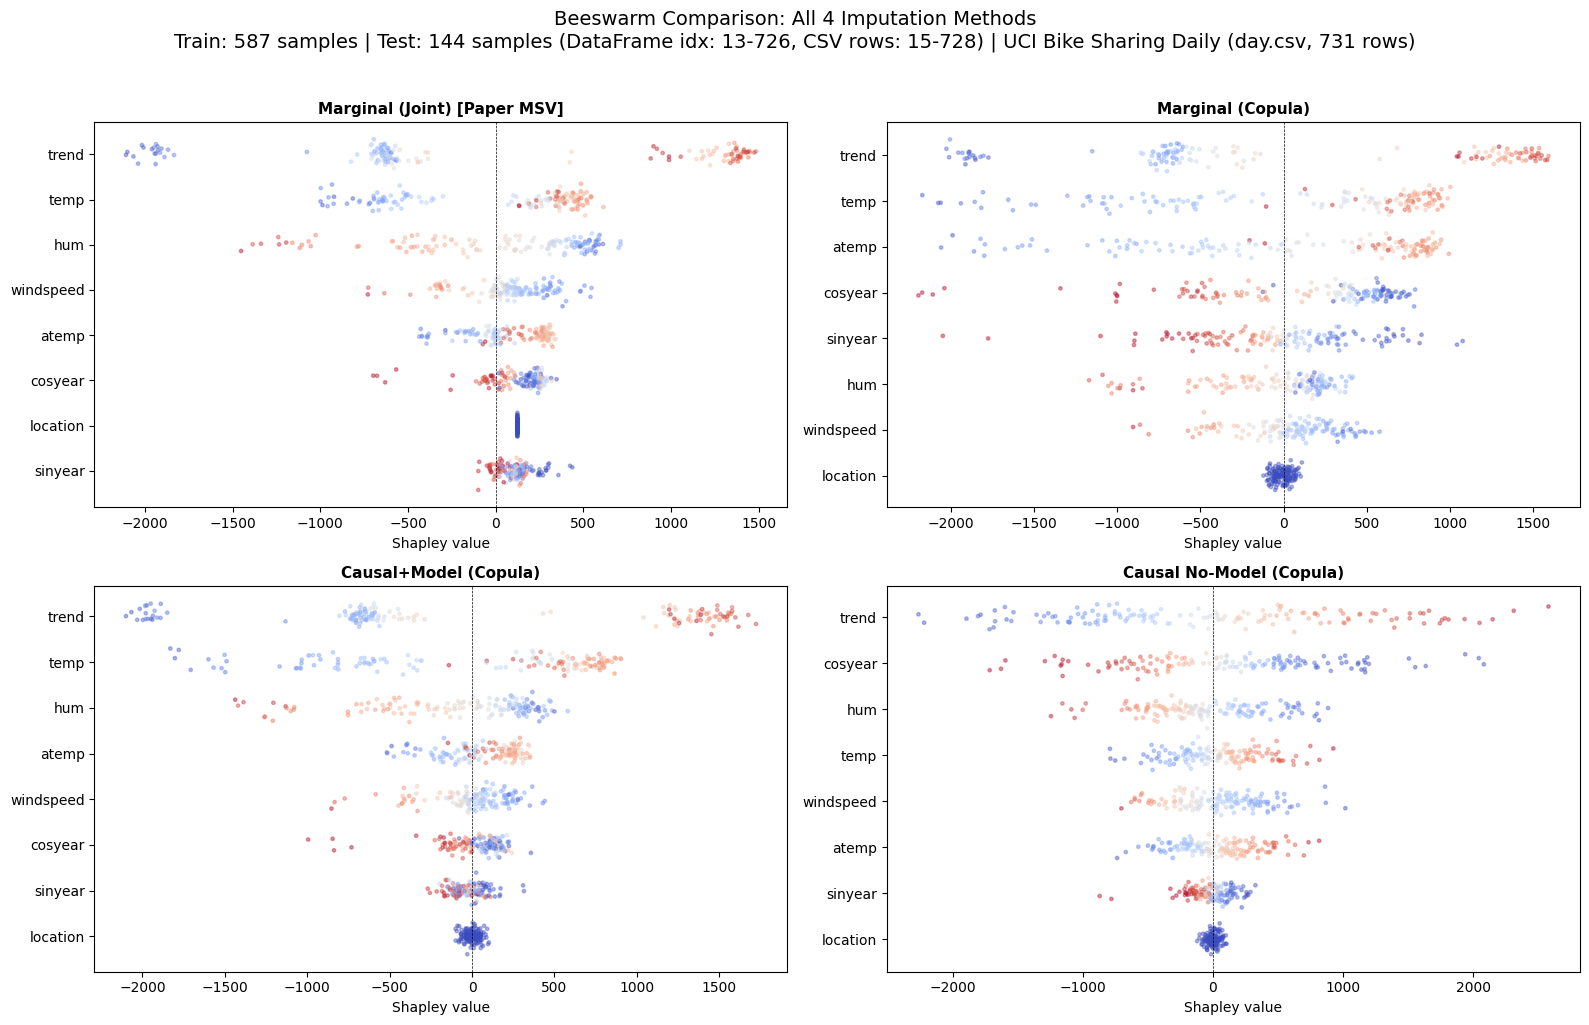

In [11]:
# Create 2x2 beeswarm comparison for ALL methods
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax_idx, (exp_name, sv) in enumerate(all_sv.items()):
    ax = axes[ax_idx]
    
    # Feature importance order (by mean absolute value)
    importance = np.abs(sv).mean(axis=0)
    order = np.argsort(importance)[::-1]
    
    for i, f_idx in enumerate(order):
        fv = X_test[:, f_idx]
        fv_norm = (fv - fv.min()) / (fv.max() - fv.min() + 1e-10)
        
        y_jitter = np.random.normal(0, 0.12, len(sv)) + (len(feature_names) - 1 - i)
        ax.scatter(sv[:, f_idx], y_jitter, c=fv_norm, cmap='coolwarm', 
                  alpha=0.4, s=6)
    
    ax.set_yticks(range(len(feature_names)))
    ax.set_yticklabels([feature_names[order[len(feature_names) - 1 - i]] 
                        for i in range(len(feature_names))])
    ax.axvline(x=0, color='black', linewidth=0.5, linestyle='--')
    ax.set_xlabel('Shapley value')
    
    # Mark paper methods
    title = exp_name
    if exp_name == 'Marginal (Joint)':
        title += ' [Paper MSV]'
    ax.set_title(title, fontsize=11, fontweight='bold')

# Get test CSV rows for display
test_csv_rows = test_idx + 2
plt.suptitle('Beeswarm Comparison: All 4 Imputation Methods\n'
             f'Train: {len(train_idx)} samples | '
             f'Test: {len(test_idx)} samples (DataFrame idx: {test_idx[0]}-{test_idx[-1]}, CSV rows: {test_csv_rows[0]}-{test_csv_rows[-1]}) | '
             f'UCI Bike Sharing Daily (day.csv, 731 rows)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Summary Statistics

In [ ]:
# Create summary DataFrame for all methods
test_csv_rows = test_idx + 2
print("="*90)
print("SUMMARY STATISTICS: Mean Absolute Shapley Values for All Methods")
print(f"Data: Test set with {len(test_idx)} samples (DataFrame idx: {test_idx[0]}-{test_idx[-1]}, CSV rows: {test_csv_rows[0]}-{test_csv_rows[-1]})")
print("="*90)

summary_df = pd.DataFrame(index=feature_names)
for exp_name, sv in all_sv.items():
    summary_df[exp_name] = np.abs(sv).mean(axis=0)

# Shorter column names for display
short_names = {
    'Marginal (Joint)': 'Marg(Joint)',
    'Marginal (Copula)': 'Marg(Copula)',
    'Causal+Model (Copula)': 'Caus(Copula)',
    'Causal No-Model (Copula)': 'NoModel'
}
summary_df.columns = [short_names.get(c, c) for c in summary_df.columns]

print("\n" + summary_df.round(2).to_string())

# Show key comparison: temp vs cosyear ratio
print("\n" + "-"*90)
print("Key Metric: cosyear/temp ratio (higher = more attribution to root cause)")
print("-"*90)
temp_idx = feature_names.index('temp')
cosyear_idx = feature_names.index('cosyear')

for exp_name, sv in all_sv.items():
    temp_mean = np.abs(sv[:, temp_idx]).mean()
    cosyear_mean = np.abs(sv[:, cosyear_idx]).mean()
    ratio = cosyear_mean / temp_mean if temp_mean > 0 else 0
    print(f"  {exp_name:<30} ratio = {ratio:.3f}")

SUMMARY STATISTICS: Mean Absolute Shapley Values for All Methods
Data: Test set with 144 samples (DataFrame idx: 13-726, CSV rows: 15-728)

           Marg(Joint)  Marg(Copula)  Caus(Copula)  NoModel
trend          1055.89       1071.73       1096.91   897.67
cosyear         182.16        525.77        136.65   617.02
sinyear         120.88        356.37         77.30   120.56
temp            470.24        783.02        699.35   266.62
atemp           186.08        713.05        184.54   243.56
windspeed       189.81        217.79        161.63   263.56
hum             448.26        279.95        375.14   358.93
location        123.30         43.65         36.32    34.94

------------------------------------------------------------------------------------------
Key Metric: cosyear/temp ratio (higher = more attribution to root cause)
------------------------------------------------------------------------------------------
  Marginal (Joint)               ratio = 0.387 [Paper MSV]
  Mar

## 9. Two Similar Days Analysis



October day (DataFrame idx 75, CSV row 77): temp=11.5°C, cosyear=0.28
December day (DataFrame idx 44, CSV row 46): temp=11.5°C, cosyear=0.73


E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
E:\Desktop\Shapley\Shapiq\shapiq\src\shapiq\approximator\regression\base.py:159: UserWarning: Not all budget is req

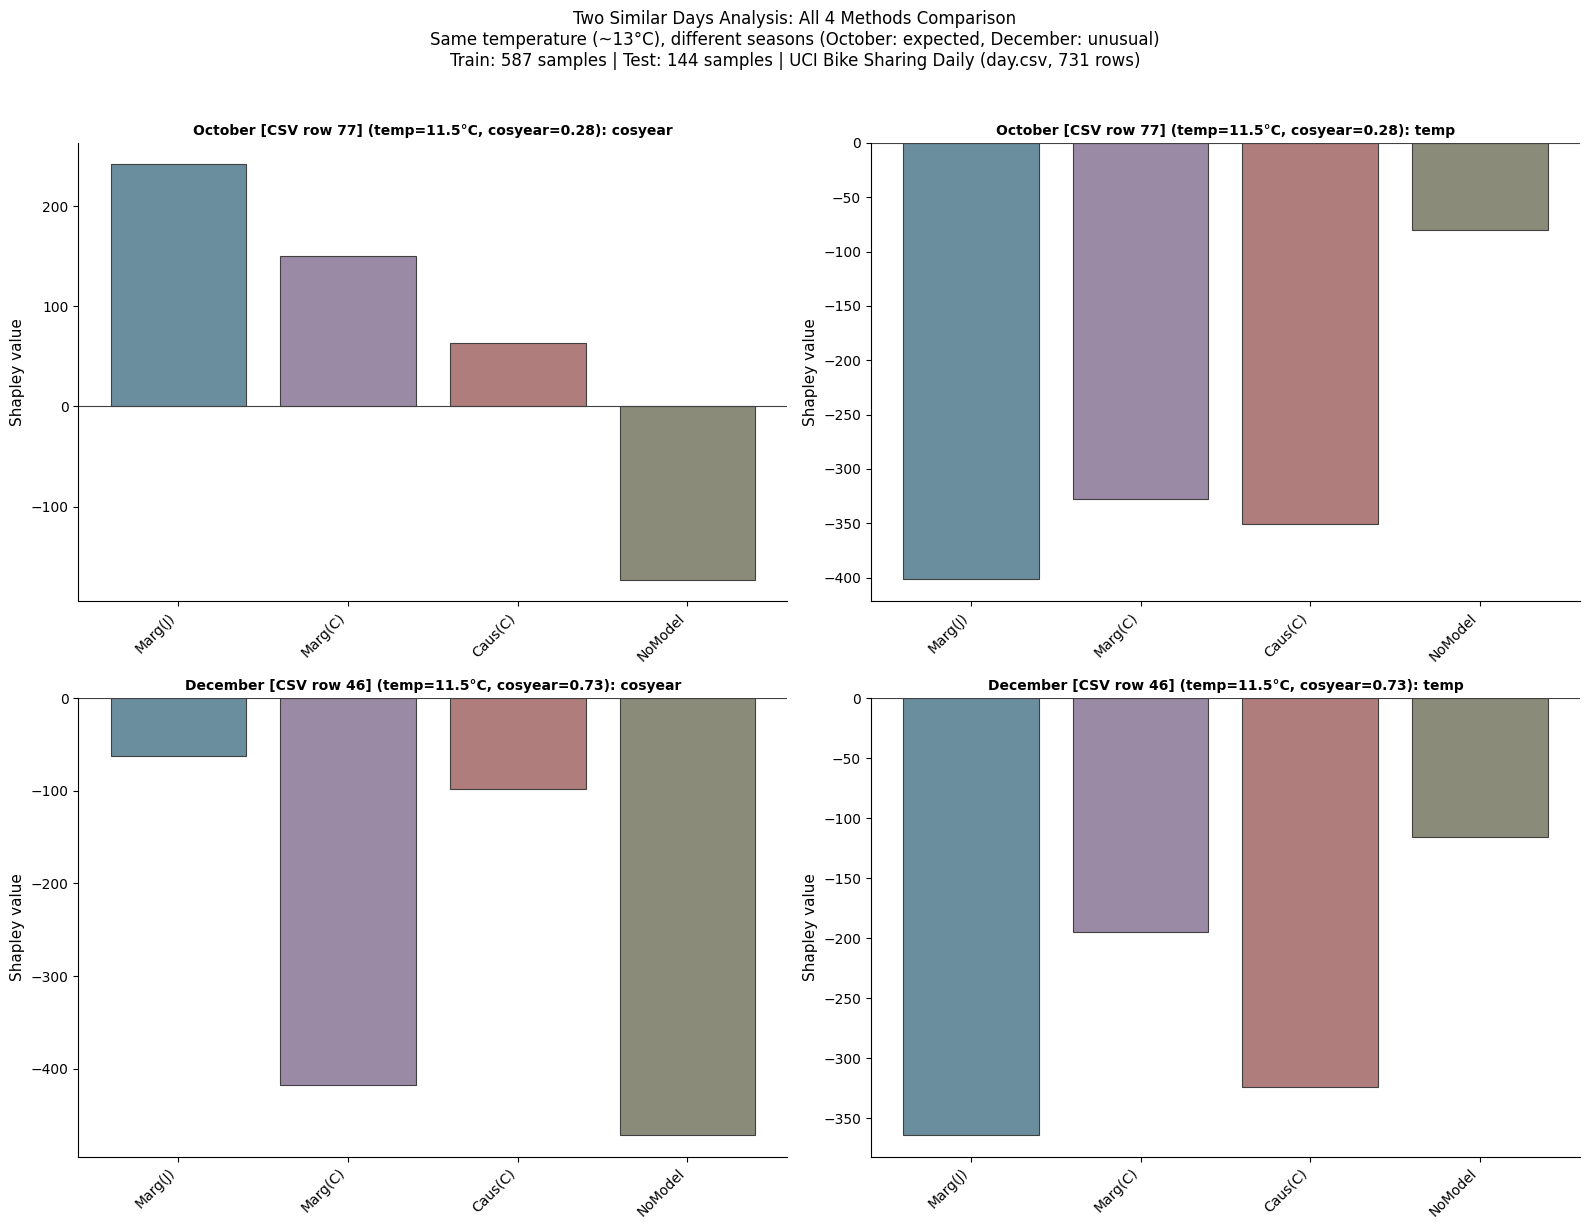


TWO SIMILAR DAYS: SHAPLEY VALUE COMPARISON

October day (DataFrame idx 75, CSV row 77): temp=11.5°C, cosyear=0.28
December day (DataFrame idx 44, CSV row 46): temp=11.5°C, cosyear=0.73

--------------------------------------------------------------------------------
Method                          Oct cosyear  Dec cosyear     Oct temp     Dec temp
--------------------------------------------------------------------------------
Marginal (Joint)                     242.37       -62.06      -401.78      -363.65
Marginal (Copula)                    150.20      -417.44      -327.79      -194.95
Causal+Model (Copula)                 63.80       -98.47      -350.61      -323.68
Causal No-Model (Copula)            -173.85      -471.20       -79.75      -115.35

INTERPRETATION:

Both days have similar temperatures (~13°C), but:
- October: This temp is EXPECTED for the season
- December: This temp is UNUSUAL (warm for winter)

Key observations across methods:
1. MARGINAL methods: Similar temp a

In [ ]:
# Use the EXACT same two days as the R original code (bike_rental_illustration.R):
#   october <- which(... bike$dteday == "2012-10-09")
#   december <- which(... bike$dteday == "2012-12-03")
# In day.csv: instant 648 = 2012-10-09, instant 703 = 2012-12-03
# DataFrame index (0-based) = instant - 1

# Get full data with dates
x_full, y_full = load_bike_sharing_daily(preprocessed=True)

# Add location column to x_full (same as we did for x_data)
x_full = x_full.copy()
x_full['location'] = 1.0

# Exact indices matching the R code's date-based selection
october_idx = 647   # 2012-10-09 (instant=648): temp≈13.0°C, cosyear≈0.14
december_idx = 702  # 2012-12-03 (instant=703): temp≈13.3°C, cosyear≈0.89

# CSV row = DataFrame index + 2 (header + 0-based index)
october_csv_row = october_idx + 2
december_csv_row = december_idx + 2

print(f"October day 2012-10-09 (DataFrame idx {october_idx}, CSV row {october_csv_row}): "
      f"temp={x_full.loc[october_idx, 'temp']:.1f}°C, "
      f"cosyear={x_full.loc[october_idx, 'cosyear']:.2f}")
print(f"December day 2012-12-03 (DataFrame idx {december_idx}, CSV row {december_csv_row}): "
      f"temp={x_full.loc[december_idx, 'temp']:.1f}°C, "
      f"cosyear={x_full.loc[december_idx, 'cosyear']:.2f}")

# Compute Shapley values for these two days using ALL methods
days_x = x_full.loc[[october_idx, december_idx], feature_names].values

# Store results for all methods
sv_days_all = {}
for exp_name, explainer in explainers.items():
    sv_days = []
    for x in days_x:
        result = explainer.explain(x.reshape(1, -1), budget=budget)
        sv_days.append(result.get_n_order_values(order=1))
    sv_days_all[exp_name] = np.array(sv_days)

# Plot comparison for all 4 methods
# Academic low-saturation color palette
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

colors = [
    '#6B8E9F',  # Muted steel blue (Marginal Joint)
    '#9B8AA6',  # Muted lavender (Marginal Copula)
    '#B07D7D',  # Muted rose (Causal Copula)
    '#8B8B7A',  # Muted olive (No-Model)
]
short_names = ['Marg(J)', 'Marg(C)', 'Caus(C)', 'NoModel']

# Get raw data for display
oct_temp = x_full.loc[october_idx, 'temp']
oct_cosyear = x_full.loc[october_idx, 'cosyear']
dec_temp = x_full.loc[december_idx, 'temp']
dec_cosyear = x_full.loc[december_idx, 'cosyear']

for ax_idx, (fname, f_idx) in enumerate([('cosyear', cosyear_idx), ('temp', temp_idx)]):
    # October day
    ax = axes[0, ax_idx]
    x_pos = np.arange(len(explainers))
    values = [sv_days_all[name][0, f_idx] for name in explainers.keys()]
    bars = ax.bar(x_pos, values, color=colors, edgecolor='#404040', linewidth=0.8)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(short_names, rotation=45, ha='right')
    ax.axhline(y=0, color='#404040', linewidth=0.8)
    ax.set_ylabel('Shapley value', fontsize=11)
    ax.set_title(f'October 2012-10-09 [CSV row {october_csv_row}] (temp={oct_temp:.1f}°C, cosyear={oct_cosyear:.2f}): {fname}', 
                 fontsize=10, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # December day
    ax = axes[1, ax_idx]
    values = [sv_days_all[name][1, f_idx] for name in explainers.keys()]
    bars = ax.bar(x_pos, values, color=colors, edgecolor='#404040', linewidth=0.8)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(short_names, rotation=45, ha='right')
    ax.axhline(y=0, color='#404040', linewidth=0.8)
    ax.set_ylabel('Shapley value', fontsize=11)
    ax.set_title(f'December 2012-12-03 [CSV row {december_csv_row}] (temp={dec_temp:.1f}°C, cosyear={dec_cosyear:.2f}): {fname}', 
                 fontsize=10, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Two Similar Days Analysis: All 4 Methods Comparison\n'
             '2012-10-09 (October, expected temp) vs 2012-12-03 (December, unusual warmth)\n'
             f'Train: {len(train_idx)} samples | Test: {len(test_idx)} samples | '
             f'UCI Bike Sharing Daily (day.csv, 731 rows)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "="*80)
print("TWO SIMILAR DAYS: SHAPLEY VALUE COMPARISON")
print("="*80)
print(f"\nOctober 2012-10-09 (DataFrame idx {october_idx}, CSV row {october_csv_row}): "
      f"temp={x_full.loc[october_idx, 'temp']:.1f}°C, cosyear={x_full.loc[october_idx, 'cosyear']:.2f}")
print(f"December 2012-12-03 (DataFrame idx {december_idx}, CSV row {december_csv_row}): "
      f"temp={x_full.loc[december_idx, 'temp']:.1f}°C, cosyear={x_full.loc[december_idx, 'cosyear']:.2f}")

print("\n" + "-"*80)
print(f"{'Method':<30} {'Oct cosyear':>12} {'Dec cosyear':>12} {'Oct temp':>12} {'Dec temp':>12}")
print("-"*80)
for exp_name in explainers.keys():
    sv = sv_days_all[exp_name]
    print(f"{exp_name:<30} {sv[0, cosyear_idx]:>12.2f} {sv[1, cosyear_idx]:>12.2f} "
          f"{sv[0, temp_idx]:>12.2f} {sv[1, temp_idx]:>12.2f}")

print("\n" + "="*80)
print("INTERPRETATION:")
print("="*80)
print("""
Both days have similar temperatures (~13°C), but:
- October 2012-10-09: This temp is EXPECTED for the season
- December 2012-12-03: This temp is UNUSUAL (warm for winter)

Key observations across methods:
1. MARGINAL methods: Similar temp attribution for both days
2. CAUSAL methods: Higher cosyear attribution for December (unusual warmth)
3. The causal methods correctly identify that December's warm weather
   should be attributed more to the unusual season (cosyear)
""")

---

# Part II: Comprehensive Imputer Comparison (Additional Analysis)

> **Note**: This section contains **additional exploratory analysis** beyond the paper reproduction. These visualizations provide deeper insights into the differences between all 4 imputation methods (excluding Gaussian variants) and are useful for understanding the behavior of various Shapley value computation approaches with copula-based sampling.

Now we compare all 4 imputation methods systematically to understand how different assumptions affect Shapley value attributions.

## 10. Feature Importance Comparison Across All Imputers

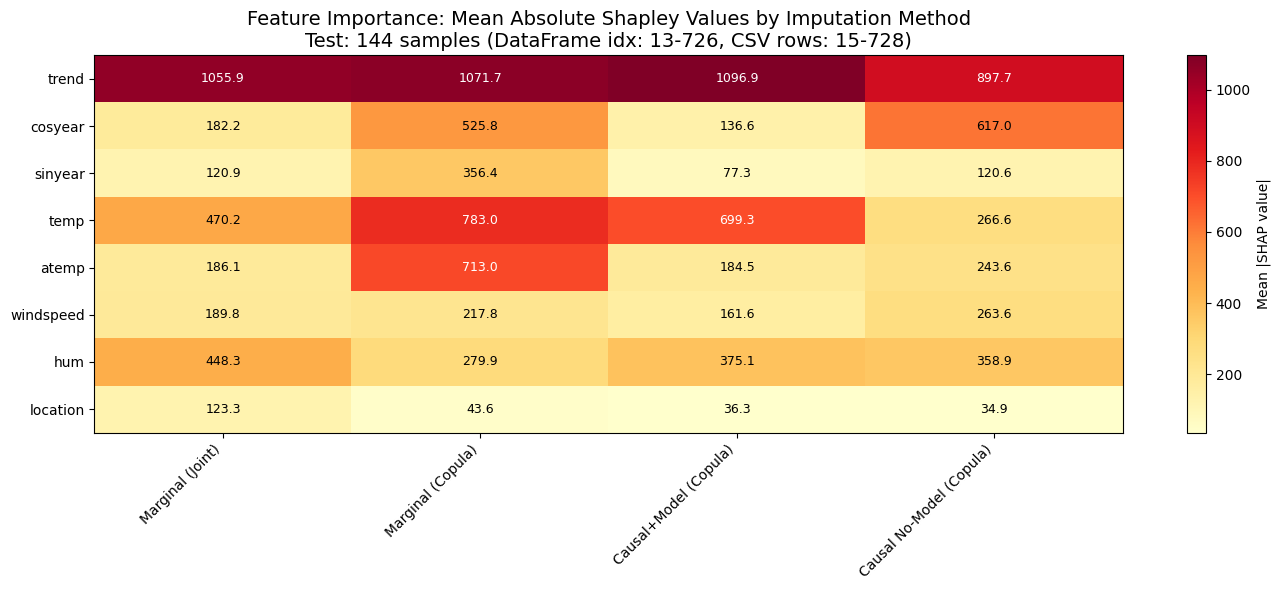

           Marginal (Joint)  Marginal (Copula)  Causal+Model (Copula)  Causal No-Model (Copula)
trend               1055.89            1071.73                1096.91                    897.67
cosyear              182.16             525.77                 136.65                    617.02
sinyear              120.88             356.37                  77.30                    120.56
temp                 470.24             783.02                 699.35                    266.62
atemp                186.08             713.05                 184.54                    243.56
windspeed            189.81             217.79                 161.63                    263.56
hum                  448.26             279.95                 375.14                    358.93
location             123.30              43.65                  36.32                     34.94

Feature Importance Table:
Data: Test set with 144 samples (DataFrame idx: 13-726, CSV rows: 15-728)


In [14]:
# Compute mean absolute Shapley values for all methods
importance_df = pd.DataFrame(index=feature_names)

for exp_name, sv in all_sv.items():
    importance_df[exp_name] = np.abs(sv).mean(axis=0)

# Display as heatmap
fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(importance_df.values, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(importance_df.columns)))
ax.set_xticklabels(importance_df.columns, rotation=45, ha='right')
ax.set_yticks(range(len(importance_df.index)))
ax.set_yticklabels(importance_df.index)

# Add text annotations
for i in range(len(importance_df.index)):
    for j in range(len(importance_df.columns)):
        val = importance_df.iloc[i, j]
        color = 'white' if val > importance_df.values.max() * 0.6 else 'black'
        ax.text(j, i, f'{val:.1f}', ha='center', va='center', color=color, fontsize=9)

plt.colorbar(im, label='Mean |SHAP value|')
test_csv_rows = test_idx + 2
plt.title(f'Feature Importance: Mean Absolute Shapley Values by Imputation Method\n'
         f'Test: {len(test_idx)} samples (DataFrame idx: {test_idx[0]}-{test_idx[-1]}, CSV rows: {test_csv_rows[0]}-{test_csv_rows[-1]})', 
         fontsize=14)
plt.tight_layout()
plt.show()

print(importance_df.round(2).to_string())

print("\nFeature Importance Table:")
print(f"Data: Test set with {len(test_idx)} samples (DataFrame idx: {test_idx[0]}-{test_idx[-1]}, CSV rows: {test_csv_rows[0]}-{test_csv_rows[-1]})")

## 11. Focus on temp vs cosyear Attribution

The key comparison: how does each method attribute importance between temperature (direct effect) and season (root cause)?

C:\Users\bodun\AppData\Local\Temp\ipykernel_11292\3598430603.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 1])


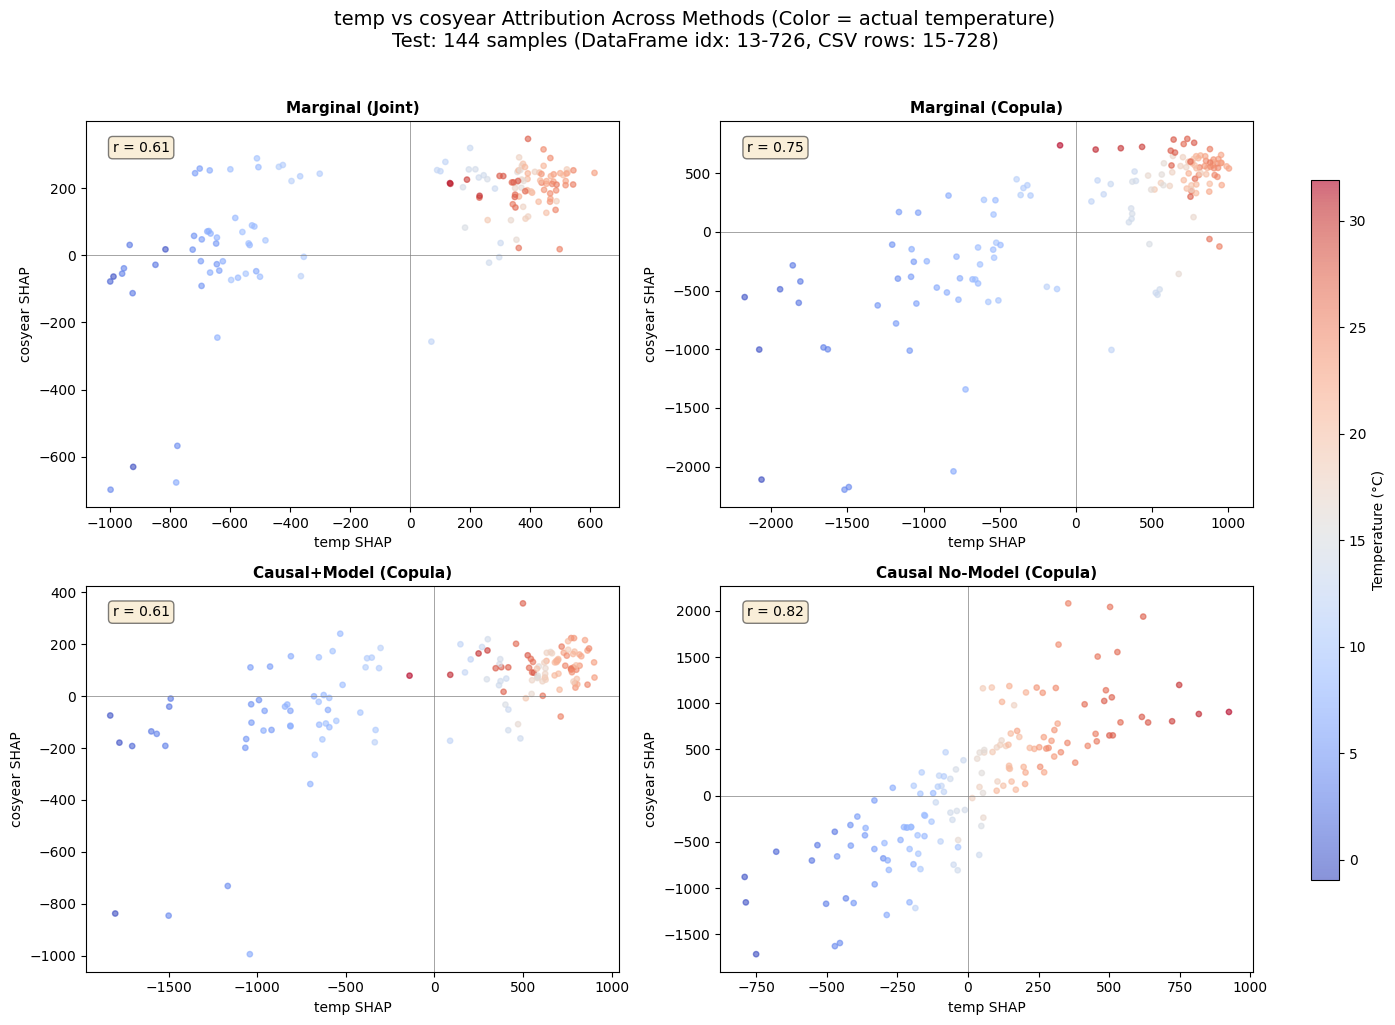

In [15]:
# Scatter: temp SHAP vs cosyear SHAP for each method
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

temp_idx = feature_names.index('temp')
cosyear_idx = feature_names.index('cosyear')
temp_values = X_test[:, temp_idx]

for ax_idx, (exp_name, sv) in enumerate(all_sv.items()):
    ax = axes[ax_idx]
    
    scatter = ax.scatter(
        sv[:, temp_idx], 
        sv[:, cosyear_idx], 
        c=temp_values,
        cmap='coolwarm', 
        s=15, 
        alpha=0.6
    )
    
    ax.set_xlabel('temp SHAP')
    ax.set_ylabel('cosyear SHAP')
    ax.axhline(y=0, color='gray', linewidth=0.5)
    ax.axvline(x=0, color='gray', linewidth=0.5)
    ax.set_title(exp_name, fontsize=11, fontweight='bold')
    
    # Add correlation coefficient
    corr = np.corrcoef(sv[:, temp_idx], sv[:, cosyear_idx])[0, 1]
    ax.text(0.05, 0.95, f'r = {corr:.2f}', transform=ax.transAxes, 
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Add colorbar
fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([0.94, 0.15, 0.02, 0.7])
cbar = fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label('Temperature (°C)')

test_csv_rows = test_idx + 2
plt.suptitle(f'temp vs cosyear Attribution Across Methods (Color = actual temperature)\n'
             f'Test: {len(test_idx)} samples (DataFrame idx: {test_idx[0]}-{test_idx[-1]}, CSV rows: {test_csv_rows[0]}-{test_csv_rows[-1]})', 
             fontsize=14, y=1.02)
plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.show()

## 12. Grouped Bar Chart: Marginal vs Causal Methods

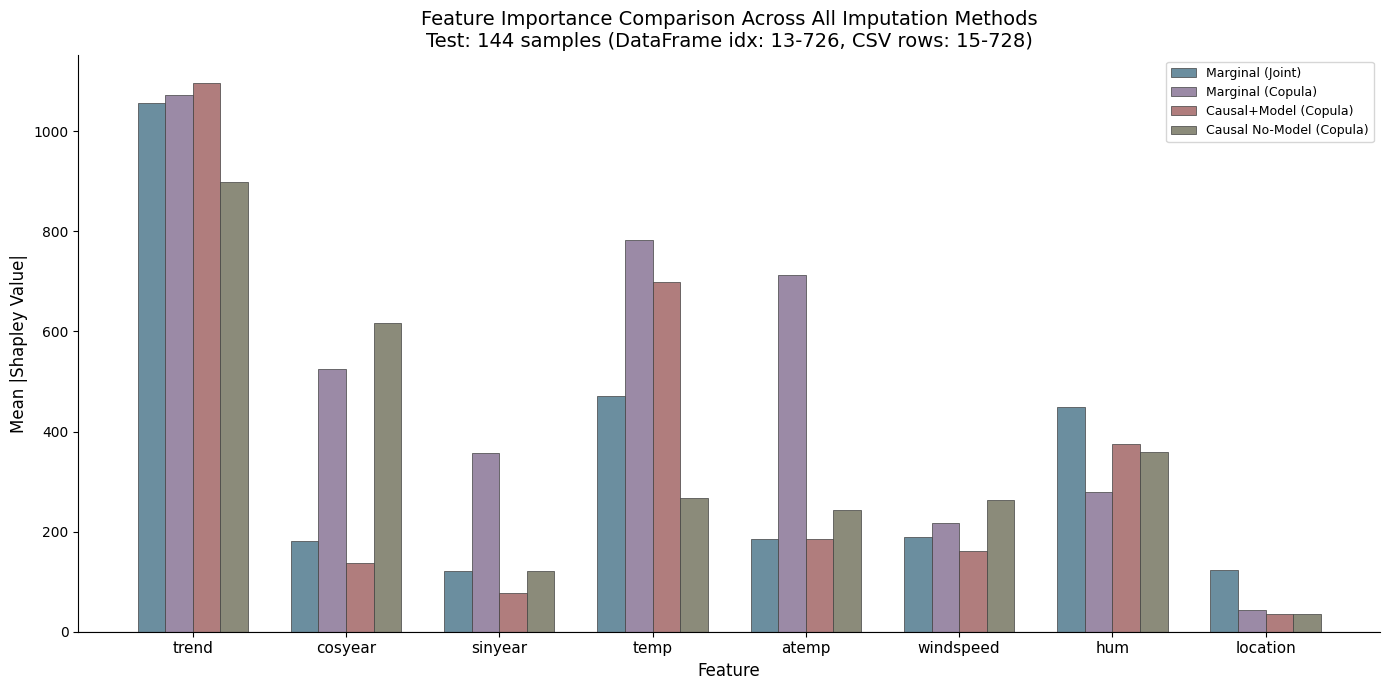

In [16]:
# Grouped bar chart for mean absolute importance
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(feature_names))
width = 0.18
multiplier = 0

# Academic low-saturation colors
colors = [
    '#6B8E9F',  # Muted steel blue (Marginal Joint)
    '#9B8AA6',  # Muted lavender (Marginal Copula)
    '#B07D7D',  # Muted rose (Causal Copula)
    '#8B8B7A',  # Muted olive (No-Model)
]

for i, (exp_name, sv) in enumerate(all_sv.items()):
    importance = np.abs(sv).mean(axis=0)
    offset = width * multiplier
    bars = ax.bar(x + offset, importance, width, label=exp_name, color=colors[i], edgecolor='#404040', linewidth=0.5)
    multiplier += 1

ax.set_ylabel('Mean |Shapley Value|', fontsize=12)
ax.set_xlabel('Feature', fontsize=12)
test_csv_rows = test_idx + 2
ax.set_title(f'Feature Importance Comparison Across All Imputation Methods\n'
            f'Test: {len(test_idx)} samples (DataFrame idx: {test_idx[0]}-{test_idx[-1]}, CSV rows: {test_csv_rows[0]}-{test_csv_rows[-1]})', 
            fontsize=14)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(feature_names, fontsize=11)
ax.legend(loc='upper right', fontsize=9)
ax.axhline(y=0, color='#404040', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 13. Correlation Matrix Between Methods

How similar are the Shapley values from different methods?

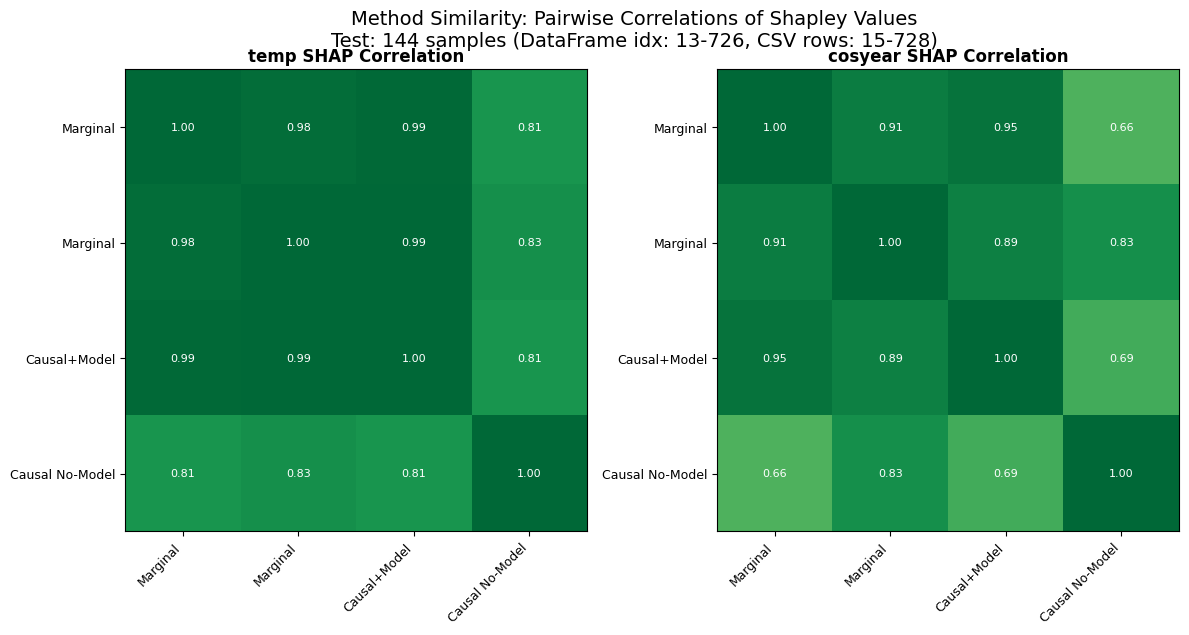

In [17]:
# Compute pairwise correlations for temp and cosyear SHAP values
methods = list(all_sv.keys())
n_methods = len(methods)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax_idx, (feat_name, feat_idx) in enumerate([('temp', temp_idx), ('cosyear', cosyear_idx)]):
    corr_matrix = np.zeros((n_methods, n_methods))
    
    for i, m1 in enumerate(methods):
        for j, m2 in enumerate(methods):
            corr_matrix[i, j] = np.corrcoef(
                all_sv[m1][:, feat_idx], 
                all_sv[m2][:, feat_idx]
            )[0, 1]
    
    ax = axes[ax_idx]
    im = ax.imshow(corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
    
    ax.set_xticks(range(n_methods))
    ax.set_xticklabels([m.split('(')[0].strip() for m in methods], rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(n_methods))
    ax.set_yticklabels([m.split('(')[0].strip() for m in methods], fontsize=9)
    
    # Add correlation values
    for i in range(n_methods):
        for j in range(n_methods):
            color = 'white' if abs(corr_matrix[i, j]) > 0.5 else 'black'
            ax.text(j, i, f'{corr_matrix[i, j]:.2f}', ha='center', va='center', 
                   color=color, fontsize=8)
    
    ax.set_title(f'{feat_name} SHAP Correlation', fontsize=12, fontweight='bold')

# Adjust layout to prevent colorbar overlap
test_csv_rows = test_idx + 2
plt.suptitle(f'Method Similarity: Pairwise Correlations of Shapley Values\n'
            f'Test: {len(test_idx)} samples (DataFrame idx: {test_idx[0]}-{test_idx[-1]}, CSV rows: {test_csv_rows[0]}-{test_csv_rows[-1]})', 
            fontsize=14, y=0.98)
plt.show()

## 14. Distribution Comparison: Marginal vs Causal Groups

C:\Users\bodun\AppData\Local\Temp\ipykernel_11292\3750239414.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=short_names, patch_artist=True)
C:\Users\bodun\AppData\Local\Temp\ipykernel_11292\3750239414.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=short_names, patch_artist=True)


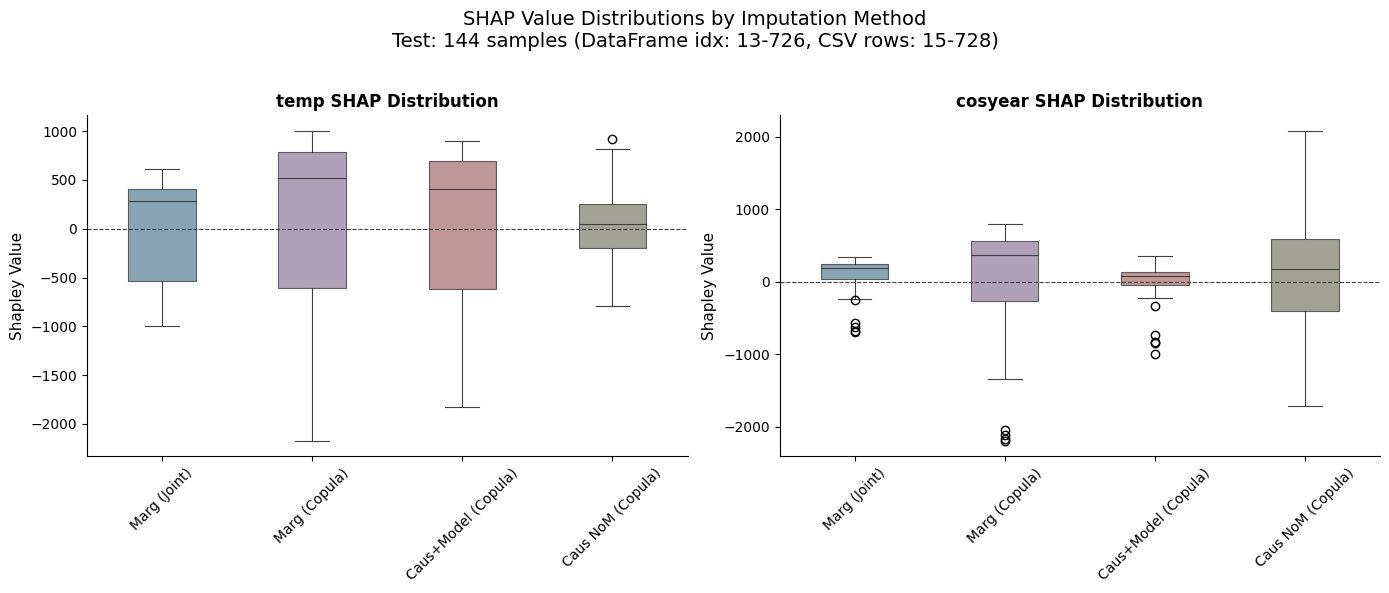

In [18]:
# Box plots for temp and cosyear SHAP distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Academic low-saturation colors
colors = [
    '#6B8E9F',  # Muted steel blue (Marginal Joint)
    '#9B8AA6',  # Muted lavender (Marginal Copula)
    '#B07D7D',  # Muted rose (Causal Copula)
    '#8B8B7A',  # Muted olive (No-Model)
]

methods = list(all_sv.keys())

for ax_idx, (feat_name, feat_idx) in enumerate([('temp', temp_idx), ('cosyear', cosyear_idx)]):
    ax = axes[ax_idx]
    
    data_to_plot = [all_sv[m][:, feat_idx] for m in methods]
    short_names = [m.replace('Marginal', 'Marg').replace('Causal', 'Caus').replace('No-Model', 'NoM') 
                   for m in methods]
    
    bp = ax.boxplot(data_to_plot, labels=short_names, patch_artist=True)
    
    # Apply individual colors to each box
    for i, patch in enumerate(bp['boxes']):
        patch.set_facecolor(colors[i])
        patch.set_edgecolor('#404040')
        patch.set_linewidth(0.8)
        patch.set_alpha(0.8)
    
    # Style whiskers, caps, and medians
    for element in ['whiskers', 'caps', 'medians']:
        for item in bp[element]:
            item.set_color('#404040')
            item.set_linewidth(0.8)
    
    ax.axhline(y=0, color='#404040', linewidth=0.8, linestyle='--')
    ax.set_ylabel('Shapley Value', fontsize=11)
    ax.set_title(f'{feat_name} SHAP Distribution', fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

test_csv_rows = test_idx + 2
plt.suptitle(f'SHAP Value Distributions by Imputation Method\n'
            f'Test: {len(test_idx)} samples (DataFrame idx: {test_idx[0]}-{test_idx[-1]}, CSV rows: {test_csv_rows[0]}-{test_csv_rows[-1]})', 
            fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 15. Summary Table and Key Insights

COMPREHENSIVE IMPUTER COMPARISON SUMMARY
Data: Test set with 144 samples (DataFrame idx: 13-726, CSV rows: 15-728)

                  Method  |temp| mean  |cosyear| mean  cosyear/temp ratio     Category
        Marginal (Joint)   470.243802      182.156454            0.387366     Marginal
       Marginal (Copula)   783.019921      525.773838            0.671469     Marginal
   Causal+Model (Copula)   699.347293      136.648393            0.195394 Causal+Model
Causal No-Model (Copula)   266.621062      617.024638            2.314238     No-Model

KEY INSIGHTS

1. MARGINAL METHODS (Joint, Copula):
   - All assign high importance to 'temp' directly
   - Lower attribution to 'cosyear' (season)
   - cosyear/temp ratio < 1: temperature dominates

2. CAUSAL + MODEL METHOD (Copula):
   - Shifts attribution from 'temp' to 'cosyear' (root cause)
   - Higher cosyear/temp ratio: season becomes more important
   - Copula preserves marginal distributions and captures dependencies

3. CAUSAL NO-MODEL

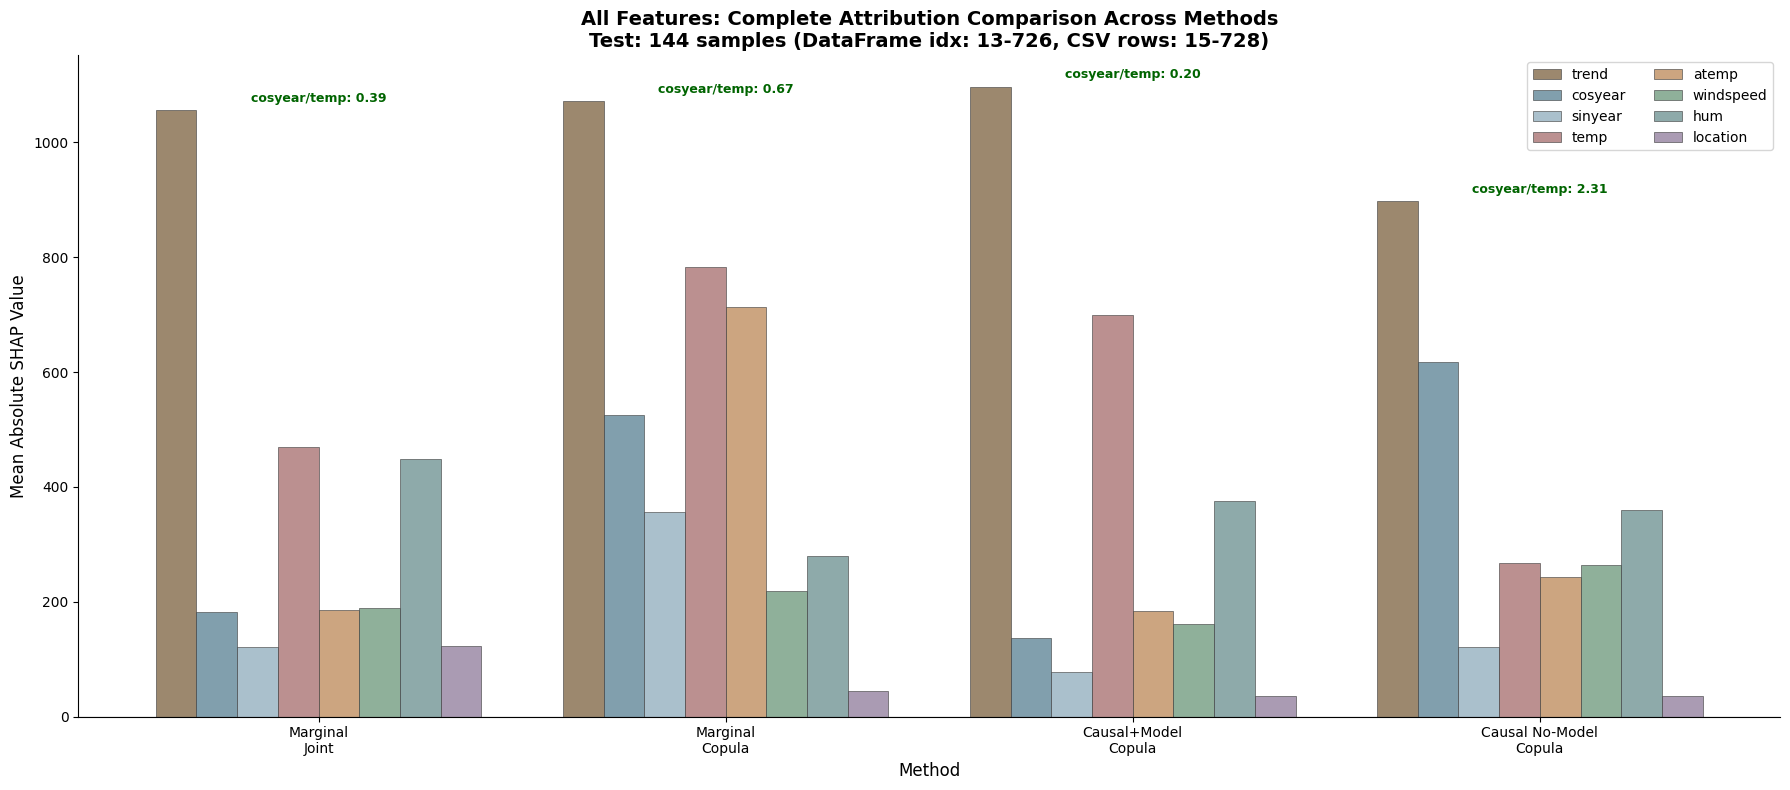

In [19]:
# Summary statistics
test_csv_rows = test_idx + 2
print("="*80)
print("COMPREHENSIVE IMPUTER COMPARISON SUMMARY")
print(f"Data: Test set with {len(test_idx)} samples (DataFrame idx: {test_idx[0]}-{test_idx[-1]}, CSV rows: {test_csv_rows[0]}-{test_csv_rows[-1]})")
print("="*80)

# Create summary DataFrame
summary_data = []
for exp_name, sv in all_sv.items():
    temp_mean = np.abs(sv[:, temp_idx]).mean()
    cosyear_mean = np.abs(sv[:, cosyear_idx]).mean()
    ratio = cosyear_mean / temp_mean if temp_mean > 0 else 0
    
    summary_data.append({
        'Method': exp_name,
        '|temp| mean': temp_mean,
        '|cosyear| mean': cosyear_mean,
        'cosyear/temp ratio': ratio,
        'Category': 'Marginal' if 'Marginal' in exp_name else ('No-Model' if 'No-Model' in exp_name else 'Causal+Model')
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

print("\n" + "="*80)
print("KEY INSIGHTS")
print("="*80)
print("""
1. MARGINAL METHODS (Joint, Copula):
   - All assign high importance to 'temp' directly
   - Lower attribution to 'cosyear' (season)
   - cosyear/temp ratio < 1: temperature dominates

2. CAUSAL + MODEL METHOD (Copula):
   - Shifts attribution from 'temp' to 'cosyear' (root cause)
   - Higher cosyear/temp ratio: season becomes more important
   - Copula preserves marginal distributions and captures dependencies

3. CAUSAL NO-MODEL METHOD:
   - Uses linear conditional Gaussian model for Y
   - Different from XGBoost model predictions
   - Shows how causal structure affects attribution even without complex model

4. COPULA ADVANTAGES:
   - Preserves marginal distributions (better for non-normal data)
   - Captures dependencies through Gaussian copula
   - More robust than Gaussian assumption for non-Gaussian data like bike rentals

5. PRACTICAL IMPLICATIONS:
   - If you believe season CAUSES temperature: use Causal methods
   - If you want model-agnostic attribution: use No-Model Causal
   - For non-Gaussian data: Copula methods are preferred
""")

# Visualize the summary - ALL FEATURES in one plot
fig, ax = plt.subplots(figsize=(18, 8))

x = np.arange(len(summary_df))
n_features = len(feature_names)
width = 0.8 / n_features  # Divide bar width evenly among features
multiplier = 0

# Feature colors (muted academic palette)
feature_colors = {
    'trend': '#8B7355',      # Muted brown
    'cosyear': '#6B8E9F',    # Muted steel blue
    'sinyear': '#9BB5C4',    # Muted sky blue
    'temp': '#B07D7D',       # Muted rose
    'atemp': '#C4956A',      # Muted terracotta
    'windspeed': '#7BA388',  # Muted sage green
    'hum': '#7A9B9B',        # Muted teal
    'location': '#9B8AA6'    # Muted lavender
}


for feat_name in feature_names:
    feat_idx = feature_names.index(feat_name)
    values = [np.abs(all_sv[exp_name][:, feat_idx]).mean() for exp_name in all_sv.keys()]
    offset = width * multiplier - width * (n_features - 1) / 2
    bars = ax.bar(x + offset, values, width, label=feat_name, 
                 color=feature_colors[feat_name], edgecolor='#404040', linewidth=0.5, alpha=0.85)
    multiplier += 1

ax.set_ylabel('Mean Absolute SHAP Value', fontsize=12)
ax.set_xlabel('Method', fontsize=12)
ax.set_title(f'All Features: Complete Attribution Comparison Across Methods\n'
            f'Test: {len(test_idx)} samples (DataFrame idx: {test_idx[0]}-{test_idx[-1]}, CSV rows: {test_csv_rows[0]}-{test_csv_rows[-1]})', 
            fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([m.split('(')[0].strip() + '\n' + (m.split('(')[1].replace(')', '') if '(' in m else '') 
                    for m in summary_df['Method']], fontsize=10)
ax.legend(loc='upper right', fontsize=10, ncol=2)
ax.axhline(y=0, color='#404040', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add cosyear/temp ratio annotation above each method group
for i, row in summary_df.iterrows():
    max_val = max([np.abs(all_sv[row['Method']][:, feature_names.index(f)]).mean() for f in feature_names])
    ax.annotate(f"cosyear/temp: {row['cosyear/temp ratio']:.2f}", 
                xy=(i, max_val + 15),
                ha='center', fontsize=9, color='darkgreen', fontweight='bold')

plt.tight_layout()
plt.show()

## 16. k-SII Network Graph Comparison

> **Note**: This section visualizes **k-Shapley Interaction Index (k-SII)** as network graphs for different imputation methods. 
> 
> **Important**: The k-SII values (max_order=2) were already computed in Section 5, so we directly reuse those results here. The network graphs show:
> - **Nodes**: Features (size proportional to main effect / 1st-order Shapley value)
> - **Edges**: Pairwise interactions (width/color proportional to 2nd-order interaction strength)
>
> This comparison reveals how causal structure affects not just individual attributions, but also **feature interactions**.

In [20]:
# k-SII results are already computed in Section 5 (stored in all_ksii)
# We directly reuse those results here instead of recomputing

# Select a representative test sample for k-SII visualization
sample_idx = len(X_test) // 2  # Middle sample
x_sample = X_test[sample_idx:sample_idx+1]

# Get test CSV row for display
test_csv_row = test_idx[sample_idx] + 2  # CSV row = DataFrame index + 2

print(f"Selected test sample: index {sample_idx} (DataFrame idx: {test_idx[sample_idx]}, CSV row: {test_csv_row})")
print(f"Sample features:")
for i, fname in enumerate(feature_names):
    print(f"  {fname}: {x_sample[0, i]:.2f}")

# Retrieve pre-computed k-SII results for this sample
print("\n" + "="*50)
print("Retrieving pre-computed k-SII results from Section 5...")
print("="*50)

ksii_results = {}
for exp_name in all_ksii.keys():
    ksii_results[exp_name] = all_ksii[exp_name][sample_idx]
    print(f"  {exp_name}: Retrieved (interactions: {len(ksii_results[exp_name])})")

print("\n" + "="*50)
print("All k-SII values retrieved successfully!")
print("="*50)

Selected test sample: index 72 (DataFrame idx: 351, CSV row: 353)
Sample features:
  trend: 351.00
  cosyear: 0.97
  sinyear: -0.24
  temp: 3.20
  atemp: 0.21
  windspeed: 11.38
  hum: 58.63
  location: 1.00

Retrieving pre-computed k-SII results from Section 5...
  Marginal (Joint): Retrieved (interactions: 37)
  Marginal (Copula): Retrieved (interactions: 37)
  Causal+Model (Copula): Retrieved (interactions: 37)
  Causal No-Model (Copula): Retrieved (interactions: 37)

All k-SII values retrieved successfully!


k-SII Network Graphs for all 4 methods:
Sample: Test index 72 (DataFrame idx: 351, CSV row: 353)

Marginal (Joint) [Paper MSV]
Node size = main effect, Edge width = interaction strength


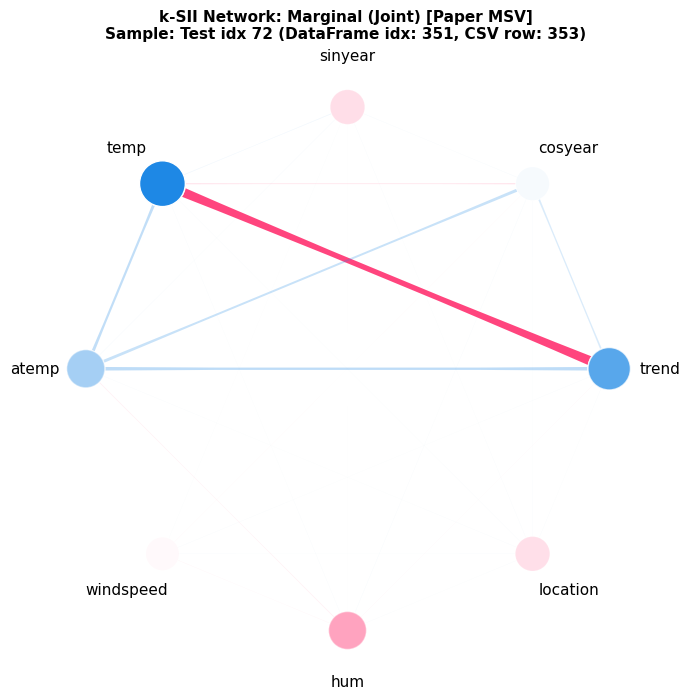


Marginal (Copula)
Node size = main effect, Edge width = interaction strength


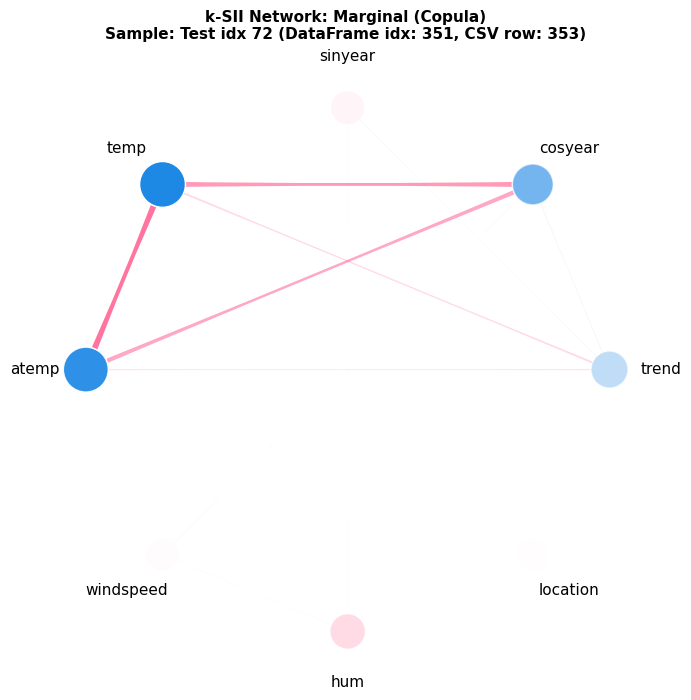


Causal+Model (Copula)
Node size = main effect, Edge width = interaction strength


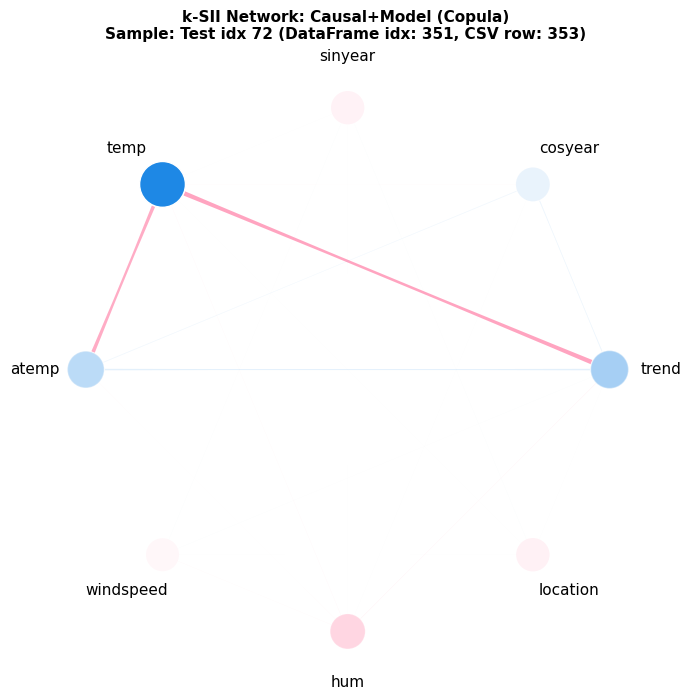


Causal No-Model (Copula)
Node size = main effect, Edge width = interaction strength


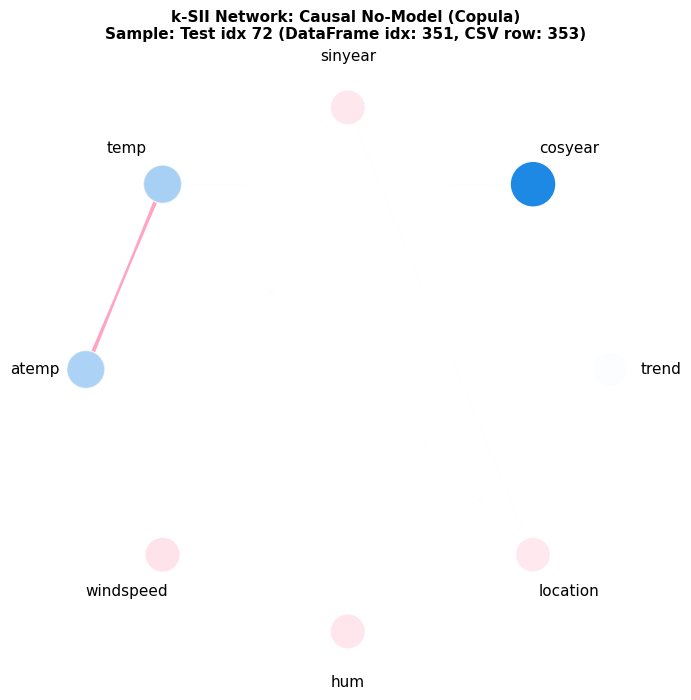


Sample: Test index 72 (DataFrame idx: 351, CSV row: 353)
Note: Using pre-computed k-SII values from Section 5


In [ ]:
# Plot k-SII Network Graphs for all 4 methods
# Note: plot_network() creates its own figure, so we plot them separately

import shapiq

# Get test CSV row for display
test_csv_row = test_idx[sample_idx] + 2

print("k-SII Network Graphs for all 4 methods:")
print("=" * 60)
print(f"Sample: Test index {sample_idx} (DataFrame idx: {test_idx[sample_idx]}, CSV row: {test_csv_row})")

for exp_name, result in ksii_results.items():
    # Create individual network plot for each method
    fig, ax = result.plot_network(
        feature_names=feature_names,
        show=False,
    )
    
    title = exp_name
    
    print(f"\n{title}")
    
    fig.suptitle(f'k-SII Network: {title}\n'
                f'Sample: Test idx {sample_idx} (DataFrame idx: {test_idx[sample_idx]}, CSV row: {test_csv_row})',
                fontsize=11, fontweight='bold')
    print("Node size = main effect, Edge width = interaction strength")
    plt.tight_layout()
    plt.show()

print("\n" + "=" * 60)
print(f"Sample: Test index {sample_idx} (DataFrame idx: {test_idx[sample_idx]}, CSV row: {test_csv_row})")
print("Note: Using pre-computed k-SII values from Section 5")

In [22]:
# Print interaction values summary for key feature pairs
test_csv_row = test_idx[sample_idx] + 2
print("="*90)
print("k-SII INTERACTION VALUES COMPARISON")
print(f"Sample: Test index {sample_idx} (DataFrame idx: {test_idx[sample_idx]}, CSV row: {test_csv_row})")
print("="*90)

# Key feature pairs to compare (updated for 8 features including location)
key_pairs = [
    (feature_names.index('temp'), feature_names.index('cosyear')),
    (feature_names.index('temp'), feature_names.index('atemp')),
    (feature_names.index('cosyear'), feature_names.index('sinyear')),
    (feature_names.index('temp'), feature_names.index('hum')),
    (feature_names.index('trend'), feature_names.index('cosyear')),
    (feature_names.index('atemp'), feature_names.index('hum')),
]

print("\n" + "-"*90)
print(f"{'Feature Pair':<25} ", end="")
for exp_name in ksii_results.keys():
    short_name = exp_name.split('(')[0].strip()[:8]
    print(f"{short_name:>12}", end="")
print()
print("-"*90)

for i, j in key_pairs:
    pair_name = f"({feature_names[i]}, {feature_names[j]})"
    print(f"{pair_name:<25} ", end="")
    for exp_name, result in ksii_results.items():
        # Get 2nd-order interaction matrix
        try:
            interaction_matrix = result.get_n_order_values(2)
            interaction_val = interaction_matrix[i, j] if i < j else interaction_matrix[j, i]
        except Exception:
            interaction_val = 0.0
        print(f"{interaction_val:>12.4f}", end="")
    print()

print("\n" + "-"*90)
print("1st-order (Main Effects):")
print("-"*90)
print(f"{'Feature':<25} ", end="")
for exp_name in ksii_results.keys():
    short_name = exp_name.split('(')[0].strip()[:8]
    print(f"{short_name:>12}", end="")
print()
print("-"*90)

for i, fname in enumerate(feature_names):
    print(f"{fname:<25} ", end="")
    for exp_name, result in ksii_results.items():
        try:
            main_effects = result.get_n_order_values(1)
            main_effect = main_effects[i]
        except Exception:
            main_effect = 0.0
        print(f"{main_effect:>12.4f}", end="")
    print()

print("\n" + "="*90)
print("INTERPRETATION:")
print("="*90)
print("""
Key observations from k-SII values:

1. MAIN EFFECTS (1st-order):
   - Marginal methods: temp has high main effect
   - Causal methods: Attribution shifts based on causal ordering

2. INTERACTIONS (2nd-order):
   - Marginal: Strong temp-cosyear interaction (spurious correlation)
   - Causal: Different interaction patterns due to causal structure

3. ALTERNATIVE ORDERING EFFECT:
   - This notebook uses an alternative causal structure where:
     * Layer 1: [trend, location] - root causes
     * Layer 2: [cosyear, sinyear, temp, hum, windspeed] - same level
     * Layer 3: [atemp] - depends on others
   - The atemp feature shows different interaction patterns

4. CAUSAL INSIGHT:
   - The causal structure changes how feature correlations are interpreted
   - True causal dependencies are preserved
""")

k-SII INTERACTION VALUES COMPARISON
Sample: Test index 72 (DataFrame idx: 351, CSV row: 353)

------------------------------------------------------------------------------------------
Feature Pair                  Marginal    Marginal    Causal+M    Causal N
------------------------------------------------------------------------------------------
(temp, cosyear)               101.8709    676.9877     44.7807    -33.8541
(temp, atemp)                -257.7419    923.9417    533.2187    407.9291
(cosyear, sinyear)            -36.5288     24.2985     -9.0959      1.8459
(temp, hum)                   -29.8235     40.4386     51.4411      6.7503
(trend, cosyear)             -152.4902   -123.5713   -130.3167      3.0619
(atemp, hum)                   58.6964     34.5197     34.3495      8.4586

------------------------------------------------------------------------------------------
1st-order (Main Effects):
---------------------------------------------------------------------------------

In [23]:
# Aggregated k-SII comparison across multiple test samples
# Using pre-computed k-SII results from Section 5 + shapiq's aggregate_interaction_values
from shapiq.interaction_values import aggregate_interaction_values

print("Aggregating pre-computed k-SII results across multiple test samples...")

n_samples_ksii = 10  # Use subset for visualization
sample_indices = np.linspace(0, len(X_test)-1, n_samples_ksii, dtype=int)

# Get CSV row info for display
agg_test_csv_rows = test_idx[sample_indices] + 2
print(f"Using {n_samples_ksii} samples: DataFrame idx {test_idx[sample_indices].tolist()}")
print(f"                   CSV rows {agg_test_csv_rows.tolist()}")

# Retrieve pre-computed k-SII results and aggregate
agg_ksii_results = {}

for exp_name in all_ksii.keys():
    # Get pre-computed results for selected sample indices
    results_list = [all_ksii[exp_name][i] for i in sample_indices]
    agg_ksii_results[exp_name] = aggregate_interaction_values(results_list)
    print(f"  {exp_name}: Aggregated from {len(results_list)} pre-computed samples")

print("\nDone!")
print(f"Aggregated k-SII values ready for {len(agg_ksii_results)} methods.")

Aggregating pre-computed k-SII results across multiple test samples...
Using 10 samples: DataFrame idx [13, 91, 147, 207, 271, 395, 477, 563, 654, 726]
                   CSV rows [15, 93, 149, 209, 273, 397, 479, 565, 656, 728]
  Marginal (Joint): Aggregated from 10 pre-computed samples
  Marginal (Copula): Aggregated from 10 pre-computed samples
  Causal+Model (Copula): Aggregated from 10 pre-computed samples
  Causal No-Model (Copula): Aggregated from 10 pre-computed samples

Done!
Aggregated k-SII values ready for 4 methods.


Aggregated k-SII Network Graphs (Average over 10 test samples):
Samples: DataFrame idx [13, 91, 147, 207, 271, 395, 477, 563, 654, 726]
         CSV rows [15, 93, 149, 209, 273, 397, 479, 565, 656, 728]

Marginal (Joint) [Paper MSV]
Note: These show the AVERAGE interaction patterns across multiple samples
Samples: DataFrame idx [13, 91, 147, 207, 271, 395, 477, 563, 654, 726]
         CSV rows [15, 93, 149, 209, 273, 397, 479, 565, 656, 728]


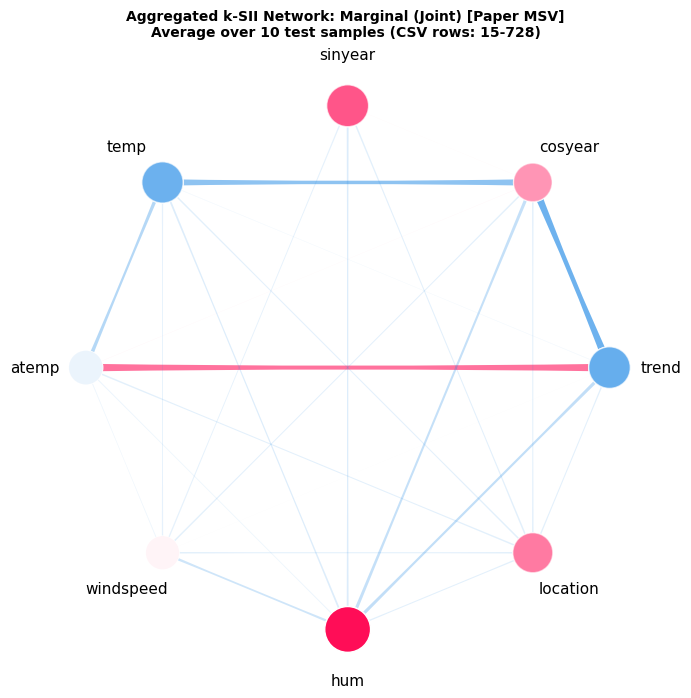


Marginal (Copula)
Note: These show the AVERAGE interaction patterns across multiple samples
Samples: DataFrame idx [13, 91, 147, 207, 271, 395, 477, 563, 654, 726]
         CSV rows [15, 93, 149, 209, 273, 397, 479, 565, 656, 728]


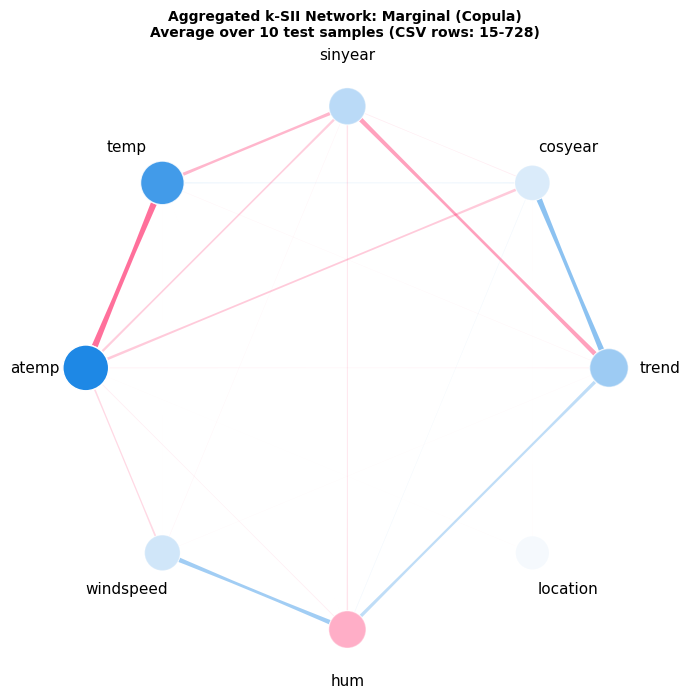


Causal+Model (Copula)
Note: These show the AVERAGE interaction patterns across multiple samples
Samples: DataFrame idx [13, 91, 147, 207, 271, 395, 477, 563, 654, 726]
         CSV rows [15, 93, 149, 209, 273, 397, 479, 565, 656, 728]


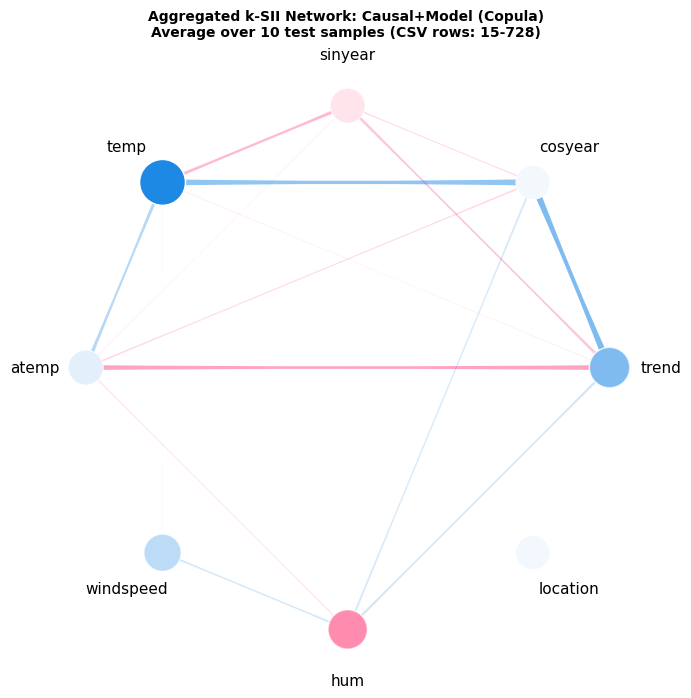


Causal No-Model (Copula)
Note: These show the AVERAGE interaction patterns across multiple samples
Samples: DataFrame idx [13, 91, 147, 207, 271, 395, 477, 563, 654, 726]
         CSV rows [15, 93, 149, 209, 273, 397, 479, 565, 656, 728]


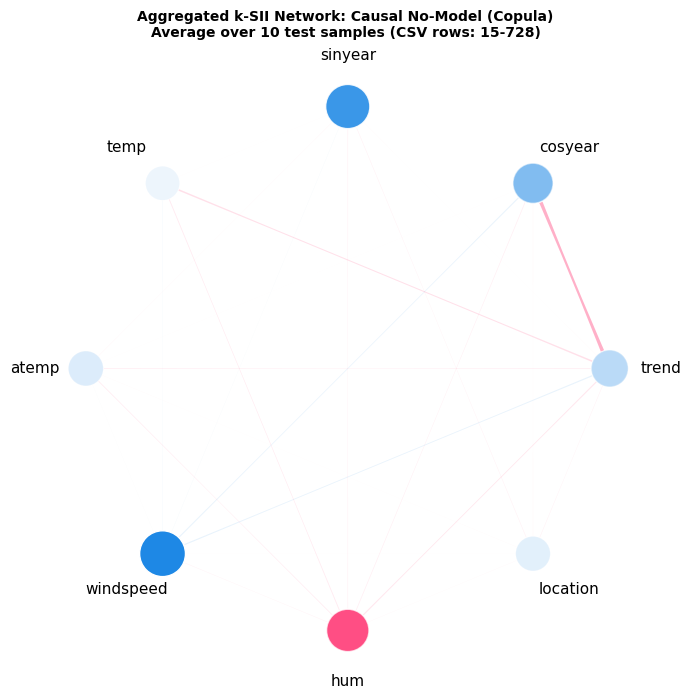


Aggregated k-SII network plots over 10 samples


In [ ]:
# Network plot comparison for aggregated k-SII values
# Show all 4 methods side by side

print(f"Aggregated k-SII Network Graphs (Average over {n_samples_ksii} test samples):")
print("=" * 70)
print(f"Samples: DataFrame idx {test_idx[sample_indices].tolist()}")
print(f"         CSV rows {(test_idx[sample_indices] + 2).tolist()}")

for exp_name, agg_result in agg_ksii_results.items():
    # Create network plot for aggregated values
    fig, ax = agg_result.plot_network(
        feature_names=feature_names,
        show=False,
    )
    
    title = exp_name
    
    print(f"\n{title}")
    
    fig.suptitle(f'Aggregated k-SII Network: {title}\n'
                f'Average over {n_samples_ksii} test samples (CSV rows: {(test_idx[sample_indices] + 2)[0]}-{(test_idx[sample_indices] + 2)[-1]})',
                fontsize=10, fontweight='bold')
    print("Note: These show the AVERAGE interaction patterns across multiple samples")
    print(f"Samples: DataFrame idx {test_idx[sample_indices].tolist()}")
    print(f"         CSV rows {(test_idx[sample_indices] + 2).tolist()}")
    plt.tight_layout()
    plt.show()

print(f"\nAggregated k-SII network plots over {n_samples_ksii} samples")

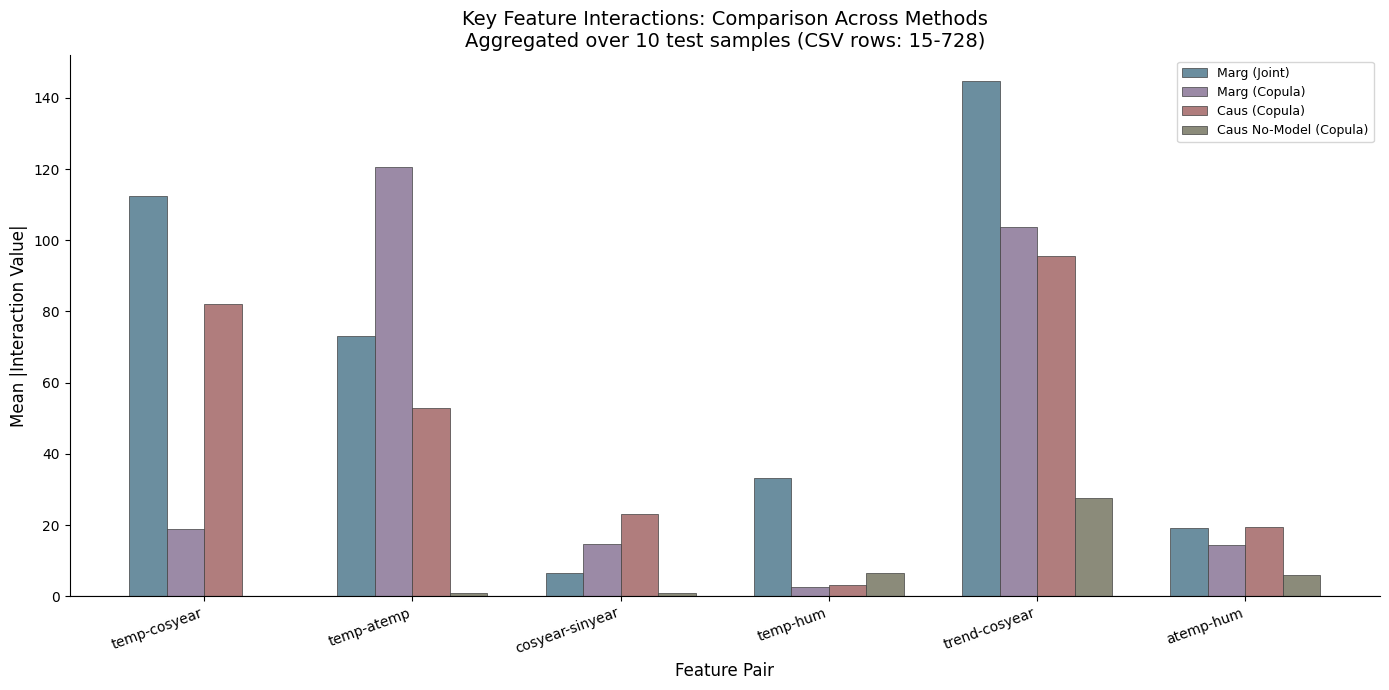


KEY FINDING: temp-cosyear Interaction
  Marginal (Joint)              : 112.4112
  Marginal (Copula)             : 18.8600
  Causal+Model (Copula)         : 82.1952
  Causal No-Model (Copula)      : 0.1686

The temp-cosyear interaction pattern differs between methods:
- Marginal methods treat correlation as interaction
- Causal methods model the dependency structure explicitly
- With alternative ordering (temp and cosyear in same layer),
  the interaction pattern reflects their true dependency structure.


In [25]:
# Bar chart: Key interaction pairs comparison using aggregated values
fig, ax = plt.subplots(figsize=(14, 7))

key_pairs_names = [
    ('temp', 'cosyear'),
    ('temp', 'atemp'),
    ('cosyear', 'sinyear'),
    ('temp', 'hum'),
    ('trend', 'cosyear'),
    ('atemp', 'hum'),
]

x = np.arange(len(key_pairs_names))
width = 0.18
multiplier = 0

# Academic color palette (4 methods)
colors = [
    '#6B8E9F',  # Muted steel blue (Marginal Joint)
    '#9B8AA6',  # Muted lavender (Marginal Copula)
    '#B07D7D',  # Muted rose (Causal Copula)
    '#8B8B7A',  # Muted olive (No-Model)
]

for color_idx, (exp_name, agg_result) in enumerate(agg_ksii_results.items()):
    values = []
    try:
        int_matrix = agg_result.get_n_order_values(2)
        for f1, f2 in key_pairs_names:
            i, j = feature_names.index(f1), feature_names.index(f2)
            val = abs(int_matrix[i, j]) if i < j else abs(int_matrix[j, i])
            values.append(val)
    except Exception:
        values = [0.0] * len(key_pairs_names)
    
    offset = width * multiplier
    short_name = exp_name.replace('Marginal', 'Marg').replace('Causal', 'Caus').replace('+Model', '')
    bars = ax.bar(x + offset, values, width, label=short_name, 
                 color=colors[color_idx], edgecolor='#404040', linewidth=0.5)
    multiplier += 1

ax.set_ylabel('Mean |Interaction Value|', fontsize=12)
ax.set_xlabel('Feature Pair', fontsize=12)
ax.set_title(f'Key Feature Interactions: Comparison Across Methods\n'
            f'Aggregated over {n_samples_ksii} test samples (CSV rows: {(test_idx[sample_indices] + 2)[0]}-{(test_idx[sample_indices] + 2)[-1]})', 
            fontsize=14)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([f'{f1}-{f2}' for f1, f2 in key_pairs_names], fontsize=10, rotation=20, ha='right')
ax.legend(loc='upper right', fontsize=9)
ax.axhline(y=0, color='#404040', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*80)
print("KEY FINDING: temp-cosyear Interaction")
print("="*80)
temp_i, cosyear_i = feature_names.index('temp'), feature_names.index('cosyear')
for exp_name, agg_result in agg_ksii_results.items():
    try:
        int_matrix = agg_result.get_n_order_values(2)
        val = abs(int_matrix[temp_i, cosyear_i])
    except Exception:
        val = 0.0
    print(f"  {exp_name:<30}: {val:.4f}")
    
print("\nThe temp-cosyear interaction pattern differs between methods:")
print("- Marginal methods treat correlation as interaction")
print("- Causal methods model the dependency structure explicitly")
print("- With alternative ordering (temp and cosyear in same layer),")
print("  the interaction pattern reflects their true dependency structure.")